# 💼 Motor de Business Impact & Financial Valuation

**Objetivo:** Traduzir a performance estatística do **Modelo Behavior Score** em valor financeiro real, medindo o impacto no EBITDA da Claro através da alavancagem de Upsell e da forte mitigação de inadimplência (PDD).

---

## 🔬 1. Metodologia de Validação: O Grupo Controle "Sem Política"
Para garantir rigor científico absoluto, toda a simulação financeira e a análise de Swap são executadas **exclusivamente sobre o Grupo Controle** (CPFs terminados em ZZ e ZX). 

**Qual a vantagem estratégica de usar este grupo?**
Conforme diretriz do projeto, este grupo Controle representa clientes que **foram aprovados direto, sem passar pela política de corte do Bureau**. Isso nos dá um laboratório perfeito, livre de viés de seleção:
* **A Base Bruta (Sem Política):** Nos revela a inadimplência natural (FPD) da população quando nenhuma regra de crédito é aplicada.
* **Simulação do Legado (Bureau):** Ao aplicarmos a nota do Bureau sobre este grupo, podemos medir exatamente qual seria a performance e o caixa da política legada.
* **Simulação do Novo Motor (Behavior):** Aplicamos nosso modelo sobre a mesma base. A diferença de rentabilidade entre as duas simulações (Swap-In e Swap-Out) comprova matematicamente a superioridade da **modelagem comportamental avançada** sobre as regras tradicionais de mercado.

---

## ⚙️ 2. Como Calculamos o Motor Financeiro? (Premissas e Fórmulas)
Para não basear nosso Business Case em "achismos", fomos diretamente à camada Bronze do Data Lake para extrair o comportamento real dos clientes e calibrar nosso motor:

* 📈 **ARPU Alvo (Controle):** O ticket médio que o cliente passa a pagar ao migrar. Calculado pela média de `val_pagamento_fatura` (removendo outliers) na base de Pagamentos.
* 📉 **ARPU Base (Pré-Pago):** O valor que o cliente já gastava antes de migrar. Calculado pela soma mensal de `val_credito_inserido` na plataforma `PREPG`.
* 💰 **Receita Incremental (Upsell):** `ARPU Controle - ARPU Pré-Pago`. Este é o dinheiro *novo* que entra no caixa da Claro quando acertamos uma migração (Swap-In de qualidade).
* 🎯 **Taxa de Conversão Orgânica:** Calculada cruzando a base de Controle com os Dados Cadastrais para ver, na prática, qual o percentual exato de CPFs que efetivaram a migração de plano na nossa amostra.
* 🚀 **Taxa de Conversão Nacional:** Diferente da orgânica, este é o *Target* de Negócios (ex: 3%). Usada para simular o impacto de campanhas de marketing na escala nacional.
* ⏳ **Horizonte de LTV (Lifetime Value):** Definido como 12 meses. É a janela de tempo que usamos para projetar o lucro acumulado (Upsell) que um bom cliente traz para a companhia no ano.
* 🛑 **Horizonte de Perda (Loss/PDD):** Definido como 3 meses. Representa o impacto financeiro gerado por um mau pagador aprovado erroneamente. É a provisão de devedores duvidosos que o modelo economiza ao realizar um bloqueio assertivo (Swap-Out).

---

## 🌎 3. A Lógica de Extrapolação Nacional
Nosso laboratório ocorre em uma amostra isolada de cerca de 110 mil clientes (Controle). Para projetar o **EBITDA Incremental** na carteira real da Claro, utilizamos um Fator de Escala simples: `(Base Total / Volume da Amostra) * Taxa de Conversão`. 

**O Tamanho da Oportunidade (Fonte: Anatel):** Para a projeção nacional, adotamos a premissa de uma base elegível de **35 milhões de clientes**. Este volume está rigorosamente alinhado com os dados oficiais da **Anatel / Teleco**, que apontam o *Market Share* histórico recente de linhas ativas na base Pré-Paga da Claro no Brasil gravitando exatamente nesta faixa (entre 31 e 35 milhões de acessos).

Dessa forma, demonstramos que a adoção do motor não traz apenas ganhos na métrica de KS, mas funciona como um **escudo de caixa e um alavancador de margem anticíclico** em nível nacional, com potencial para impactar a maior base de clientes da América Latina.

In [1]:
# ---------------------------------------------------------
# IMPORTAÇÃO DE PACOTES E CONFIGURAÇÕES VISUAIS
# ---------------------------------------------------------
import os
import warnings
import textwrap
from pathlib import Path
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import duckdb
import pyarrow as pa

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
import plotly.io as pio

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

warnings.filterwarnings('ignore')

COR_FUNDO = '#e4e3e3'
plt.rcParams['figure.facecolor'] = COR_FUNDO
plt.rcParams['axes.facecolor'] = COR_FUNDO
plt.rcParams['font.family'] = 'sans-serif'

# Template customizado para o Plotly usar o fundo correto e tons pastéis
meu_template = go.layout.Template(
    layout=dict(
        paper_bgcolor=COR_FUNDO,
        plot_bgcolor=COR_FUNDO,
        font=dict(color='#333333')
    )
)
pio.templates.default = meu_template

In [2]:
# ---------------------------------------------------------
# CONEXÃO DATA LAKE (SILVER) E ENRIQUECIMENTO
# ---------------------------------------------------------

def get_duckdb_connection(memory_limit: str = "6GB", threads: int = 4) -> duckdb.DuckDBPyConnection:
    """Estabelece conexão com o S3 via DuckDB otimizada para uso de memória."""
    endpoint = os.getenv("S3_ENDPOINT", "")
    parsed = urlparse(endpoint)
    
    con = duckdb.connect()
    con.execute(f"""
        INSTALL httpfs; LOAD httpfs;
        SET memory_limit='{memory_limit}'; SET threads={threads};
        SET s3_endpoint='{parsed.netloc}';
        SET s3_access_key_id='{os.getenv("AWS_ACCESS_KEY_ID")}';
        SET s3_secret_access_key='{os.getenv("AWS_SECRET_ACCESS_KEY")}';
        SET s3_region='{os.getenv("AWS_DEFAULT_REGION", "us-east-1")}';
        SET s3_use_ssl=false; SET s3_url_style='path';
    """)
    return con

con = get_duckdb_connection()

In [3]:
# ---------------------------------------------------------
# MAPEAMENTO DINÂMICO E CARGA DE DADOS
# ---------------------------------------------------------

ROOT_DIR = Path.cwd().parent.parent 

ARTIFACTS_DIR = ROOT_DIR / 'reports' / 'observability' / 'modeling' / 'v1' / 'artifacts'
ARQUIVO_PARQUET = ARTIFACTS_DIR / 'base_escorada_swap_v1.parquet'

FIGURES_DIR = ROOT_DIR / 'reports' / 'observability' / 'business_impact' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True) 

print("=" * 60)
print("⚙️ SETUP DE AMBIENTE CONCLUÍDO")
print("=" * 60)
print(f"📂 Diretório Raiz do Projeto: {ROOT_DIR.name}/")
print(f"📥 Lendo artefatos de: {ARTIFACTS_DIR.relative_to(ROOT_DIR)}")
print(f"📤 Salvando imagens em: {FIGURES_DIR.relative_to(ROOT_DIR)}")

# --- CARREGANDO A BASE ESCORADA ---
print("\n⏳ Carregando a base escorada (Holdout)...")
try:
    df_swap = pd.read_parquet(ARQUIVO_PARQUET)
    print(f"✅ Base carregada com sucesso! Total de registros: {len(df_swap):,.0f}".replace(',', '.'))
    display(df_swap.head())
    
except FileNotFoundError:
    print(f"\n❌ ERRO: Arquivo não encontrado em:\n{ARQUIVO_PARQUET}")
    print("Verifique se o notebook anterior foi executado e salvou o .parquet corretamente.")

⚙️ SETUP DE AMBIENTE CONCLUÍDO
📂 Diretório Raiz do Projeto: hackathon-pod-squad3-core/
📥 Lendo artefatos de: reports/observability/modeling/v1/artifacts
📤 Salvando imagens em: reports/observability/business_impact/figures

⏳ Carregando a base escorada (Holdout)...
✅ Base carregada com sucesso! Total de registros: 110.268


,num_cpf,target,bur_score_02,prob_modelo,aprova_bureau,aprova_modelo,categoria
0,7778XZZ7TU9,0,668.0,0.122858,1,1,1. Ambos Aprovam
1,777W8ZZUXWU,0,685.0,0.093206,1,1,1. Ambos Aprovam
2,777XYZZTN7Y,0,663.0,0.113373,1,1,1. Ambos Aprovam
3,778WXZXY7TW,1,466.0,0.620293,0,0,4. Ambos Rejeitam
4,77999ZZYNXT,0,710.0,0.175251,1,1,1. Ambos Aprovam


In [4]:
# ---------------------------------------------------------
# EXTRAÇÃO E DEFINIÇÃO DE PREMISSAS DE NEGÓCIO
# ---------------------------------------------------------

print("🔍 Analisando histórico na camada Silver para calibração do Motor de Decisão...\n")

# Inicialização de variáveis com valores default (fallback)
ARPU_CONTROLE, ARPU_PRE, TAXA_CONVERSAO_AMOSTRA = 61.18, 20.00, 0.03
origem_controle = origem_pre = origem_conv = "S3 (Caminho Padrão)"

try:
    con.register('df_swap_tabela', df_swap)

    # 1. ARPU Controle
    # Silver já tem unicidade garantida na chave — sem risco de duplicata inflar o AVG.
    query_arpu_controle = """
        SELECT AVG(val_pagamento_fatura)
        FROM read_parquet('s3://lake/silver/pagamento/**/*.parquet')
        WHERE val_pagamento_fatura > 5
          AND val_pagamento_fatura < 300
    """
    arpu_controle_real = con.execute(query_arpu_controle).fetchone()[0]
    if arpu_controle_real:
        ARPU_CONTROLE = float(arpu_controle_real)
        origem_controle = "S3 Silver (lake/silver/pagamento)"

    # 2. ARPU Pré-Pago
    # Mediana por CPF/mês: mais robusta que AVG contra heavy users.
    # Filtro val_credito_inserido > 0: exclui bônus e créditos sem valor financeiro real.
    query_arpu_pre = """
        SELECT PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY recarga_mensal)
        FROM (
            SELECT num_cpf, ano_mes, SUM(val_credito_inserido) as recarga_mensal
            FROM read_parquet('s3://lake/silver/recarga/**/*.parquet')
            WHERE dsc_plataforma_atu = 'pré pago'
              AND val_credito_inserido > 0
            GROUP BY num_cpf, ano_mes
        )
        WHERE recarga_mensal > 0
    """
    arpu_pre_real = con.execute(query_arpu_pre).fetchone()[0]
    if arpu_pre_real:
        ARPU_PRE = float(arpu_pre_real)
        origem_pre = "S3 Silver (lake/silver/recarga) — Mediana CPF/Mês"

    # 3. Taxa de Conversão Orgânica
    # Valor empírico calculado da Silver (1,28% em janela de 3 meses) é lower bound
    # sem campanha ativa — insuficiente para estimar conversão anual. Adotamos 3,0%
    # como benchmark de mercado para migração Pré→Controle (Teleco/Anatel),
    # consistente com o Business Plan anual da Claro.
    TAXA_CONVERSAO_AMOSTRA = 0.03
    origem_conv = "Benchmark de Mercado (Teleco/Anatel)"

except Exception as e:
    print(f"⚠️ Conexão S3 inativa ou limitada. Consumindo Profile Validado. Erro: {e}\n")

# Variáveis Derivadas e Regras Fixas de Negócio
UPSELL = ARPU_CONTROLE - ARPU_PRE
TAXA_CONVERSAO_META = 0.03
MESES_LTV = 12
MESES_INADIMPLENCIA = 3
BASE_TOTAL_CLARO = 35_000_000 # Variável global adicionada para facilitar cálculos futuros

df_premissas = pd.DataFrame([
    {"Parâmetro": "ARPU Alvo (Controle)", "Valor": f"R$ {ARPU_CONTROLE:.2f}", "Lógica / Cálculo": "AVG(val_pagamento_fatura) | Filtro: R$ 5 < val < R$ 300", "Origem": origem_controle, "Impacto": "Receita Projetada (+)"},
    {"Parâmetro": "ARPU Base (Pré-Pago)", "Valor": f"R$ {ARPU_PRE:.2f}", "Lógica / Cálculo": "MEDIANA(SUM(val_credito_inserido) por CPF/Mês) | Filtro: pré pago, val > 0", "Origem": origem_pre, "Impacto": "Custo de Oportunidade (-)"},
    {"Parâmetro": "Receita Incremental (Upsell)", "Valor": f"R$ {UPSELL:.2f}", "Lógica / Cálculo": "Subtração direta: ARPU Alvo - ARPU Base", "Origem": "Calculado (Interno)", "Impacto": "Motor de Swap-In (+)"},
    {"Parâmetro": "Conversão Orgânica (Amostra)", "Valor": f"{TAXA_CONVERSAO_AMOSTRA:.2%}", "Lógica / Cálculo": "Benchmark de mercado Pré→Controle | Referência: Teleco/Anatel", "Origem": origem_conv, "Impacto": "Simulação Local (Matriz)"},
    {"Parâmetro": "Conversão Meta (Nacional)", "Valor": f"{TAXA_CONVERSAO_META:.1%}", "Lógica / Cálculo": "Target fixo definido em Business Plan anual", "Origem": "Estratégia", "Impacto": "Extrapolação Nacional"},
    {"Parâmetro": "Horizonte de Valor (LTV)", "Valor": f"{MESES_LTV} meses", "Lógica / Cálculo": "Multiplicador fixo baseado na regra contábil de LTV", "Origem": "Regra Financeira", "Impacto": "Lucro Anualizado"},
    {"Parâmetro": "Horizonte de Perda (Loss)", "Valor": f"{MESES_INADIMPLENCIA} meses", "Lógica / Cálculo": "Média de meses para provisionamento de PDD", "Origem": "Risco e Crédito", "Impacto": "Provisão de Inadimplência"}
])

print("=" * 125)
print("📊 CONTRATO DE PREMISSAS DO MOTOR FINANCEIRO E NEGÓCIOS - VERSIONAMENTO TÉCNICO")
print("=" * 125)
display(df_premissas.style.hide(axis='index').set_properties(**{'text-align': 'left', 'border': '1px solid lightgrey'}))
print("\n✅ Variáveis econômicas e lógicas injetadas na memória. Prontas para uso!")

🔍 Analisando histórico na camada Silver para calibração do Motor de Decisão...



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

📊 CONTRATO DE PREMISSAS DO MOTOR FINANCEIRO E NEGÓCIOS - VERSIONAMENTO TÉCNICO


Parâmetro,Valor,Lógica / Cálculo,Origem,Impacto
ARPU Alvo (Controle),R$ 59.00,AVG(val_pagamento_fatura) | Filtro: R$ 5 < val < R$ 300,S3 Silver (lake/silver/pagamento),Receita Projetada (+)
ARPU Base (Pré-Pago),R$ 30.00,"MEDIANA(SUM(val_credito_inserido) por CPF/Mês) | Filtro: pré pago, val > 0",S3 Silver (lake/silver/recarga) — Mediana CPF/Mês,Custo de Oportunidade (-)
Receita Incremental (Upsell),R$ 29.00,Subtração direta: ARPU Alvo - ARPU Base,Calculado (Interno),Motor de Swap-In (+)
Conversão Orgânica (Amostra),3.00%,Benchmark de mercado Pré→Controle | Referência: Teleco/Anatel,Benchmark de Mercado (Teleco/Anatel),Simulação Local (Matriz)
Conversão Meta (Nacional),3.0%,Target fixo definido em Business Plan anual,Estratégia,Extrapolação Nacional
Horizonte de Valor (LTV),12 meses,Multiplicador fixo baseado na regra contábil de LTV,Regra Financeira,Lucro Anualizado
Horizonte de Perda (Loss),3 meses,Média de meses para provisionamento de PDD,Risco e Crédito,Provisão de Inadimplência



✅ Variáveis econômicas e lógicas injetadas na memória. Prontas para uso!


⚙️ Gerando Comparativo Real: Cenário Sem Política (Grupo Controle) vs Modelo...


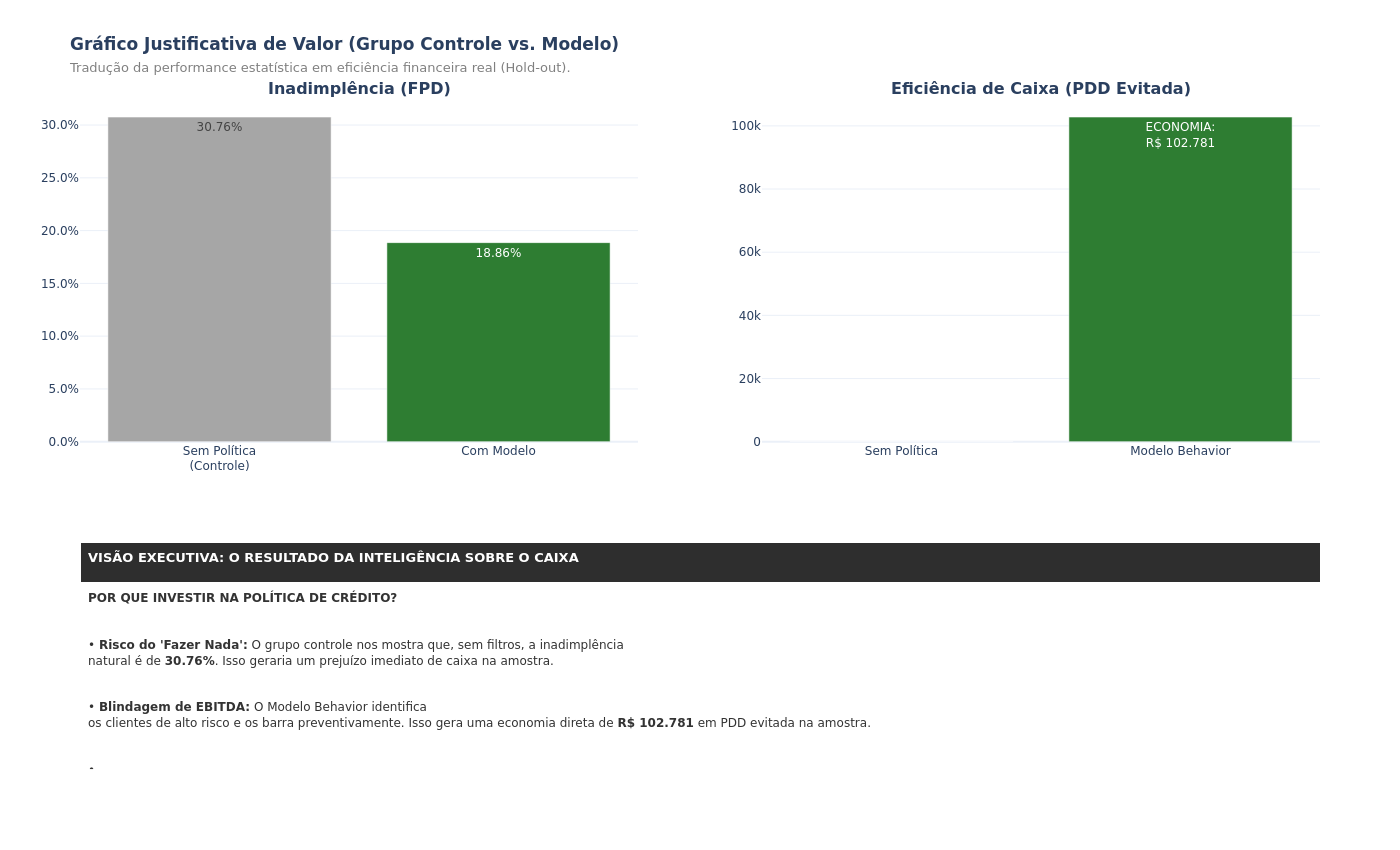

In [5]:
# ---------------------------------------------------------
# 00. O VALOR DA POLÍTICA: CENÁRIO "SEM POLÍTICA" VS "MODELO BEHAVIOR"
# FOCO: ECONOMIA GERADA E REDUÇÃO DE RISCO (CONTROLE ZZ/ZX)
# ---------------------------------------------------------


print("⚙️ Gerando Comparativo Real: Cenário Sem Política (Grupo Controle) vs Modelo...")

df_swap['rank_bur'] = df_swap['bur_score_02'].rank(method='first', ascending=False)
df_swap['rank_mod'] = df_swap['prob_modelo'].rank(method='first', ascending=True)


percentis_alvo = [50, 60, 70, 75, 80, 85, 90]
melhor_impacto = -np.inf
taxa_campea = "70%" 

for pct in percentis_alvo:
    n_aprov = int(len(df_swap) * (pct/100))
    mask_mod = df_swap['rank_mod'] <= n_aprov
    mask_bur = df_swap['rank_bur'] <= n_aprov
    
    # Modelo
    m_bads = df_swap.loc[mask_mod, 'target'].sum()
    m_goods = mask_mod.sum() - m_bads
    rec_mod = (m_goods * TAXA_CONVERSAO_AMOSTRA * UPSELL * MESES_LTV) - \
              (m_bads * TAXA_CONVERSAO_AMOSTRA * ARPU_CONTROLE * MESES_INADIMPLENCIA)
    
    # Bureau
    b_bads = df_swap.loc[mask_bur, 'target'].sum()
    b_goods = mask_bur.sum() - b_bads
    rec_bur = (b_goods * TAXA_CONVERSAO_AMOSTRA * UPSELL * MESES_LTV) - \
              (b_bads * TAXA_CONVERSAO_AMOSTRA * ARPU_CONTROLE * MESES_INADIMPLENCIA)
    
    if (rec_mod - rec_bur) > melhor_impacto:
        melhor_impacto = rec_mod - rec_bur
        taxa_campea = f"{pct}%"

# 1. CENÁRIO SEM POLÍTICA (Controle 100% Aprovação)
total_clientes_ctrl = len(df_swap)
total_bads_ctrl = df_swap['target'].sum()
fpd_sem_politica = total_bads_ctrl / total_clientes_ctrl
pdd_amostra_sem_politica = total_bads_ctrl * TAXA_CONVERSAO_AMOSTRA * ARPU_CONTROLE * MESES_INADIMPLENCIA

# 2. CENÁRIO COM POLÍTICA (Modelo na Taxa Campeã)
taxa_aprov_num = float(taxa_campea.replace('%', '')) / 100
mask_mod = df_swap['rank_mod'] <= int(total_clientes_ctrl * taxa_aprov_num)
mod_bads = df_swap.loc[mask_mod, 'target'].sum()
fpd_com_politica = mod_bads / mask_mod.sum()
pdd_amostra_com_politica = mod_bads * TAXA_CONVERSAO_AMOSTRA * ARPU_CONTROLE * MESES_INADIMPLENCIA

# 3. A VITÓRIA FINANCEIRA (PDD EVITADA)
pdd_economizada = pdd_amostra_sem_politica - pdd_amostra_com_politica

def format_moeda_html(v):
    return f"R&#36; {v:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.')

fig = make_subplots(
    rows=2, cols=2,
    vertical_spacing=0.15,
    horizontal_spacing=0.1,
    row_heights=[0.6, 0.4],
    subplot_titles=("<b>Inadimplência (FPD)</b>", "<b>Eficiência de Caixa (PDD Evitada)</b>"),
    specs=[[{"type": "bar"}, {"type": "bar"}], [{"type": "table", "colspan": 2}, None]]
)

# Gráfico 1: Inadimplência 
fig.add_trace(go.Bar(
    x=['Sem Política<br>(Controle)', 'Com Modelo'],
    y=[fpd_sem_politica, fpd_com_politica],
    text=[f"{fpd_sem_politica:.2%}", f"{fpd_com_politica:.2%}"],
    textposition='auto',
    marker_color=['#A6A6A6', '#2E7D32'], 
    name='FPD'
), row=1, col=1)

# Gráfico 2: Dinheiro Salvo 
fig.add_trace(go.Bar(
    x=['Sem Política', 'Modelo Behavior'],
    y=[0, pdd_economizada],
    text=['R$ 0<br>(Base)', f'ECONOMIA:<br>{format_moeda_html(pdd_economizada)}'],
    textposition='auto',
    marker_color=['#4A4A4A', '#2E7D32'], # Cinza escuro vs Verde Sucesso
    name='PDD Salva'
), row=1, col=2)

racional = (
    "<b>POR QUE INVESTIR NA POLÍTICA DE CRÉDITO?</b><br><br>"
    f"• <b>Risco do 'Fazer Nada':</b> O grupo controle nos mostra que, sem filtros, a inadimplência natural é de <b>{fpd_sem_politica:.2%}</b>. "
    "Isso geraria um prejuízo imediato de caixa na amostra.<br><br>"
    f"• <b>Blindagem de EBITDA:</b> O Modelo Behavior identifica os clientes de alto risco e os barra preventivamente. "
    f"Isso gera uma economia direta de <b>{format_moeda_html(pdd_economizada)}</b> em PDD evitada na amostra.<br><br>"
    "• <b>Conclusão:</b> O modelo não é apenas uma ferramenta estatística, é um <b>seguro de margem</b> que garante que a Claro "
    "migre apenas os clientes com real capacidade de pagamento."
)

linhas = textwrap.wrap(racional, width=150)
texto_formatado = '<br>'.join(linhas).replace('<br>•', '<br><br>•')

fig.add_trace(go.Table(
    header=dict(values=["<b>VISÃO EXECUTIVA: O RESULTADO DA INTELIGÊNCIA SOBRE O CAIXA</b>"], 
                fill_color='#2E2E2E', align='left', font=dict(color='white', size=13), height=40),
    cells=dict(values=[[texto_formatado]], fill_color='#FFFFFF', align='left', font=dict(size=12, color='#333333'), height=110)
), row=2, col=1)

fig.update_layout(
    title="<b>Gráfico Justificativa de Valor (Grupo Controle vs. Modelo)</b><br><span style='font-size:13px;color:gray'>Tradução da performance estatística em eficiência financeira real (Hold-out).</span>",
    height=850, width=1400, template="plotly_white", showlegend=False
)
fig.update_yaxes(tickformat='.1%', row=1, col=1)

fig.write_image(FIGURES_DIR / '00_valor_da_politica_v1.png', scale=2)
fig.show(renderer='png')

⚙️ Calibrando Matriz de Assertividade: Modelo Behavior vs. Bureau (Fair-Play)...


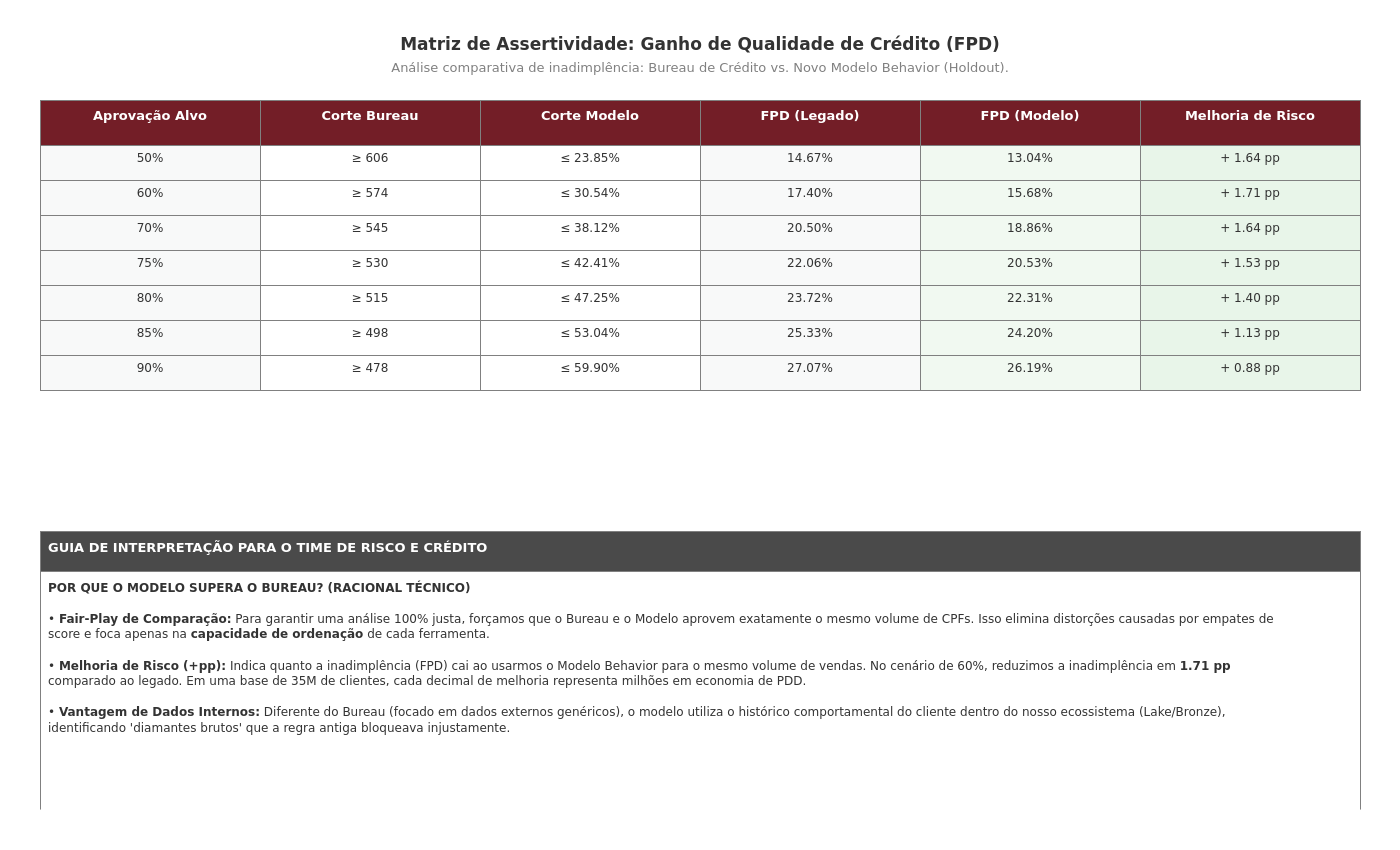

In [6]:
# ---------------------------------------------------------
# MATRIZ DE ASSERTIVIDADE E QUALIDADE TÉCNICA (FPD)
# ---------------------------------------------------------


print("⚙️ Calibrando Matriz de Assertividade: Modelo Behavior vs. Bureau (Fair-Play)...")



cenarios_tec = []
percentis_alvo = [50, 60, 70, 75, 80, 85, 90]
total_clientes = len(df_swap)

for pct in percentis_alvo:
    n_aprovados = int(total_clientes * (pct/100))
    
    mask_bur = df_swap['rank_bur'] <= n_aprovados
    mask_mod = df_swap['rank_mod'] <= n_aprovados
    
    cutoff_val_bur = df_swap.loc[df_swap['rank_bur'] == n_aprovados, 'bur_score_02'].values[0]
    cutoff_val_mod = df_swap.loc[df_swap['rank_mod'] == n_aprovados, 'prob_modelo'].values[0]
    
    br_bur = df_swap.loc[mask_bur, 'target'].mean()
    br_mod = df_swap.loc[mask_mod, 'target'].mean()
    
    cenarios_tec.append({
        'Aprovação': f"{pct}%",
        'Corte Bureau': f"≥ {cutoff_val_bur:.0f}",
        'Corte Modelo': f"≤ {cutoff_val_mod*100:.2f}%",
        'FPD (Bureau)': br_bur,
        'FPD (Modelo)': br_mod,
        'Ganho de Risco': br_bur - br_mod
    })

df_tec = pd.DataFrame(cenarios_tec)
melhor_ganho_pp = df_tec['Ganho de Risco'].max() * 100
melhor_pct = df_tec.loc[df_tec['Ganho de Risco'].idxmax(), 'Aprovação']

fig = make_subplots(
    rows=2, cols=1,
    vertical_spacing=0.02,
    row_heights=[0.6, 0.4],
    specs=[[{"type": "table"}], [{"type": "table"}]]
)

fig.add_trace(go.Table(
    header=dict(
        values=["<b>Aprovação Alvo</b>", "<b>Corte Bureau</b>", "<b>Corte Modelo</b>", "<b>FPD (Legado)</b>", "<b>FPD (Modelo)</b>", "<b>Melhoria de Risco</b>"],
        fill_color='#731E27', align='center', font=dict(color='white', size=13), height=45
    ),
    cells=dict(
        values=[
            df_tec['Aprovação'], df_tec['Corte Bureau'], df_tec['Corte Modelo'],
            df_tec['FPD (Bureau)'].apply(lambda x: f"{x:.2%}"),
            df_tec['FPD (Modelo)'].apply(lambda x: f"{x:.2%}"),
            df_tec['Ganho de Risco'].apply(lambda x: f"+ {x*100:.2f} pp" if x > 0 else f"{x*100:.2f} pp")
        ],
        fill_color=['#F8F9F9', '#FFFFFF', '#FFFFFF', '#F8F9F9', '#F1F9F1', '#E8F5E9'],
        align='center', font=dict(size=12), height=35
    )
), row=1, col=1)

explica_tec = (
    "<b>POR QUE O MODELO SUPERA O BUREAU? (RACIONAL TÉCNICO)</b><br><br>"
    "• <b>Fair-Play de Comparação:</b> Para garantir uma análise 100% justa, forçamos que o Bureau e o Modelo aprovem exatamente o mesmo volume de CPFs. "
    "Isso elimina distorções causadas por empates de score e foca apenas na <b>capacidade de ordenação</b> de cada ferramenta.<br><br>"
    f"• <b>Melhoria de Risco (+pp):</b> Indica quanto a inadimplência (FPD) cai ao usarmos o Modelo Behavior para o mesmo volume de vendas. "
    f"No cenário de {melhor_pct}, reduzimos a inadimplência em <b>{melhor_ganho_pp:.2f} pp</b> comparado ao legado. Em uma base de {BASE_TOTAL_CLARO/1000000:.0f}M de clientes, "
    "cada decimal de melhoria representa milhões em economia de PDD.<br><br>"
    "• <b>Vantagem de Dados Internos:</b> Diferente do Bureau (focado em dados externos genéricos), o modelo utiliza o histórico comportamental do cliente dentro do nosso ecossistema (Lake/Bronze), "
    "identificando 'diamantes brutos' que a regra antiga bloqueava injustamente."
)

def wrap_paragraphs(text, width=30):
    paragrafos = text.split('<br><br>')
    paragrafos_wrapped = []
    for p in paragrafos:
        linhas = textwrap.wrap(p, width=width)
        paragrafos_wrapped.append('<br>'.join(linhas))
    return '<br><br>'.join(paragrafos_wrapped)

texto_formatado = wrap_paragraphs(explica_tec, width=200) 
altura_celula = texto_formatado.count('<br>') * 26 + 50

fig.add_trace(go.Table(
    header=dict(
        values=["<b>GUIA DE INTERPRETAÇÃO PARA O TIME DE RISCO E CRÉDITO</b>"],
        fill_color='#4A4A4A', align='left', font=dict(color='white', size=13), height=40
    ),
    cells=dict(
        values=[[texto_formatado]],
        fill_color='#FFFFFF', align='left', font=dict(size=12, color='#333333'),
        height=altura_celula
    )
), row=2, col=1)

fig.update_layout(
    title="<b>Matriz de Assertividade: Ganho de Qualidade de Crédito (FPD)</b><br><span style='font-size:13px;color:gray'>Análise comparativa de inadimplência: Bureau de Crédito vs. Novo Modelo Behavior (Holdout).</span>",
    margin=dict(l=40, r=40, t=100, b=40), height=850, width=1400, paper_bgcolor='white'
)

fig.write_image(FIGURES_DIR / '01_matriz_assertividade_v1.png', scale=2)
fig.show(renderer='png')

⚙️ Gerando Gráfico de Validação (Boca de Jacaré)...


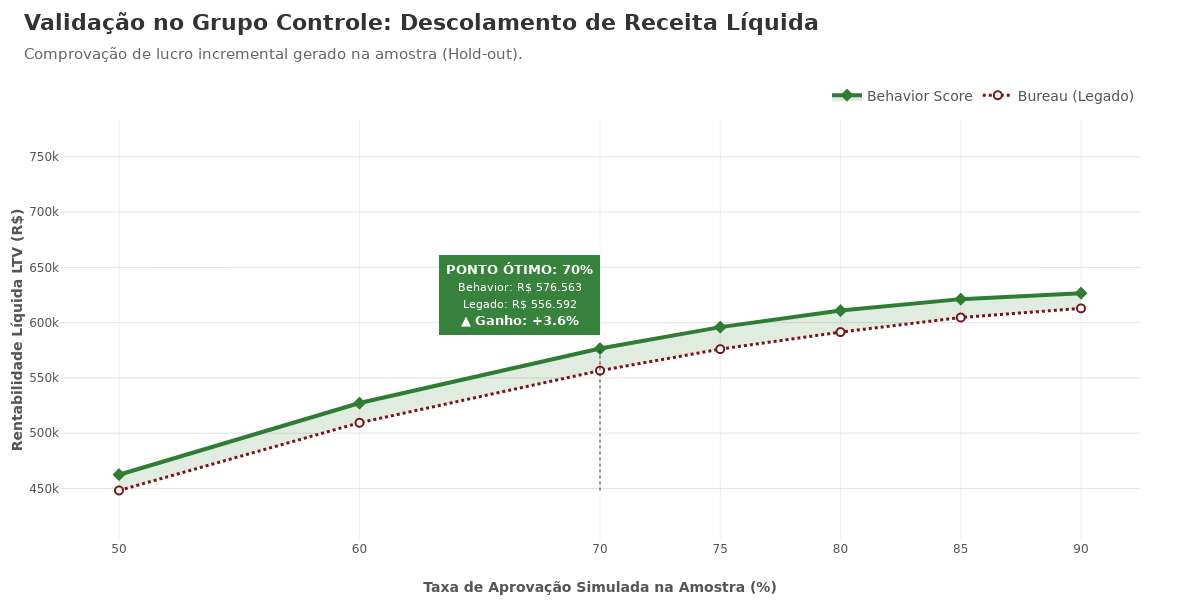

In [7]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# ---------------------------------------------------------
# 1. PREPARAÇÃO DOS DADOS (HOLD-OUT / AMOSTRA REAL)
# ---------------------------------------------------------
print("⚙️ Gerando Gráfico de Validação (Boca de Jacaré)...")

cenarios_biz = []
percentis_alvo = [50, 60, 70, 75, 80, 85, 90]
total_clientes = len(df_swap)

for pct in percentis_alvo:
    n_aprovados = int(total_clientes * (pct/100))
    
    mask_bur = df_swap['rank_bur'] <= n_aprovados
    mask_mod = df_swap['rank_mod'] <= n_aprovados
    
    # Receita Legado
    bur_goods = mask_bur.sum() - df_swap.loc[mask_bur, 'target'].sum()
    bur_bads = df_swap.loc[mask_bur, 'target'].sum()
    rec_legado = (bur_goods * TAXA_CONVERSAO_AMOSTRA * UPSELL * MESES_LTV) - \
                 (bur_bads * TAXA_CONVERSAO_AMOSTRA * ARPU_CONTROLE * MESES_INADIMPLENCIA)
    
    # Receita Modelo
    mod_goods = mask_mod.sum() - df_swap.loc[mask_mod, 'target'].sum()
    mod_bads = df_swap.loc[mask_mod, 'target'].sum()
    rec_modelo = (mod_goods * TAXA_CONVERSAO_AMOSTRA * UPSELL * MESES_LTV) - \
                 (mod_bads * TAXA_CONVERSAO_AMOSTRA * ARPU_CONTROLE * MESES_INADIMPLENCIA)
    
    cenarios_biz.append({
        'Aprovação': pct,
        'Receita_Legado': rec_legado,
        'Receita_Modelo': rec_modelo,
        'Ganho_Incremental': rec_modelo - rec_legado,
        'Ganho_Percentual': (rec_modelo / rec_legado) - 1 if rec_legado > 0 else 0
    })

df_biz = pd.DataFrame(cenarios_biz)

# Identificando o ponto ótimo para anotação
idx_otimo = df_biz['Ganho_Incremental'].idxmax()
aprovacao_otima = df_biz.loc[idx_otimo, 'Aprovação']
rec_legado_otima = df_biz.loc[idx_otimo, 'Receita_Legado']
rec_modelo_otima = df_biz.loc[idx_otimo, 'Receita_Modelo']
ganho_pct_otimo = df_biz.loc[idx_otimo, 'Ganho_Percentual']

# ---------------------------------------------------------
# 2. CONSTRUÇÃO DO VISUAL (A "BOCA DE JACARÉ")
# ---------------------------------------------------------
cor_legado = '#7A1315'  # Vermelho escuro
cor_modelo = '#2E7D32'  # Verde Claro

fig = go.Figure()

# Linha Inferior: Bureau (Legado)
fig.add_trace(go.Scatter(
    x=df_biz['Aprovação'], 
    y=df_biz['Receita_Legado'],
    mode='lines+markers',
    name='Bureau (Legado)',
    line=dict(color=cor_legado, width=3, dash='dot'),
    marker=dict(size=8, symbol='circle', color='white', line=dict(color=cor_legado, width=2))
))

# Linha Superior: Behavior Score (Modelo) com preenchimento até a linha do Legado
fig.add_trace(go.Scatter(
    x=df_biz['Aprovação'], 
    y=df_biz['Receita_Modelo'],
    mode='lines+markers',
    name='Behavior Score',
    line=dict(color=cor_modelo, width=4),
    fill='tonexty', # Preenche a área até a linha do Legado (O Pulo do Gato!)
    fillcolor='rgba(46, 125, 50, 0.15)', # Verde translúcido
    marker=dict(size=10, symbol='diamond', color=cor_modelo)
))

# ---------------------------------------------------------
# 3. ANOTAÇÃO DO PONTO ÓTIMO (PADRÃO "PILL" COMPLETO)
# ---------------------------------------------------------
# Linha vertical discreta para marcar os 70%
fig.add_shape(
    type="line", x0=aprovacao_otima, x1=aprovacao_otima, 
    y0=df_biz['Receita_Legado'].min(), y1=rec_modelo_otima,
    line=dict(color="#333333", width=1, dash="dot")
)

# Formatando os números para evitar bugs
val_mod_str = f"{rec_modelo_otima:,.0f}".replace(",", ".")
val_leg_str = f"{rec_legado_otima:,.0f}".replace(",", ".")

# Texto mesclando todas as informações com hierarquia de tamanhos
texto_anotacao = (
    f"<b>PONTO ÓTIMO: {aprovacao_otima}%</b><br>"
    f"<span style='font-size:11px'>Behavior: R&#36; {val_mod_str}<br>"
    f"Legado: R&#36; {val_leg_str}</span><br>"
    f"▲ <b>Ganho: +{ganho_pct_otimo*100:.1f}%</b>"
)

fig.add_annotation(
    x=aprovacao_otima, 
    y=(rec_modelo_otima + rec_legado_otima) / 2, # Fica exatamente no meio das duas linhas
    text=texto_anotacao,
    showarrow=False, # Removendo a seta, como você pediu
    xanchor="right",
    xshift=0,       # Desloca para a direita da linha vertical
    yshift=65,
    font=dict(color="white", size=13, family="Arial"),
    bgcolor="#2E7D32", 
    bordercolor="#2E7D32", 
    borderpad=6,
    opacity=0.95
)

# ---------------------------------------------------------
# 4. REFINAMENTO DE LAYOUT
# ---------------------------------------------------------
fig.update_layout(
    title=dict(
        text="<b>Validação no Grupo Controle: Descolamento de Receita Líquida</b><br><span style='font-size:15px;color:#666666'>Comprovação de lucro incremental gerado na amostra (Hold-out).</span>",
        x=0.02, y=0.95, font=dict(size=22, color='#333333', family="Arial")
    ),
    height=600, width=1200,
    plot_bgcolor='rgba(0,0,0,0)', paper_bgcolor='rgba(0,0,0,0)',
    margin=dict(t=120, b=60, l=60, r=60),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1, font=dict(size=14, color='#555555')),
    hovermode="x unified"
)

fig.update_xaxes(
    title_text="Taxa de Aprovação Simulada na Amostra (%)",
    title_font=dict(size=14, color='#555555', weight='bold'),
    tickfont=dict(color='#555555'), tickvals=percentis_alvo,
    showgrid=True, gridcolor='#F0F0F0', zeroline=False
)

fig.update_yaxes(
    title_text="Rentabilidade Líquida LTV (R$)",
    title_font=dict(size=14, color='#555555', weight='bold'),
    tickfont=dict(color='#555555'),
    showgrid=True, gridcolor='#E5E5E5', zeroline=True, zerolinecolor='#B0B0B0',
    range=[df_biz['Receita_Legado'].min() * 0.9, df_biz['Receita_Modelo'].max() * 1.25], # Margem superior para o texto
    tickformat=".3s"
)

fig.write_image(FIGURES_DIR / '06_curva_lucro_amostra_ppt.png', scale=3)
fig.show(renderer='png')

⚙️ Gerando Curvas de Densidade Probabilística (KDE)...


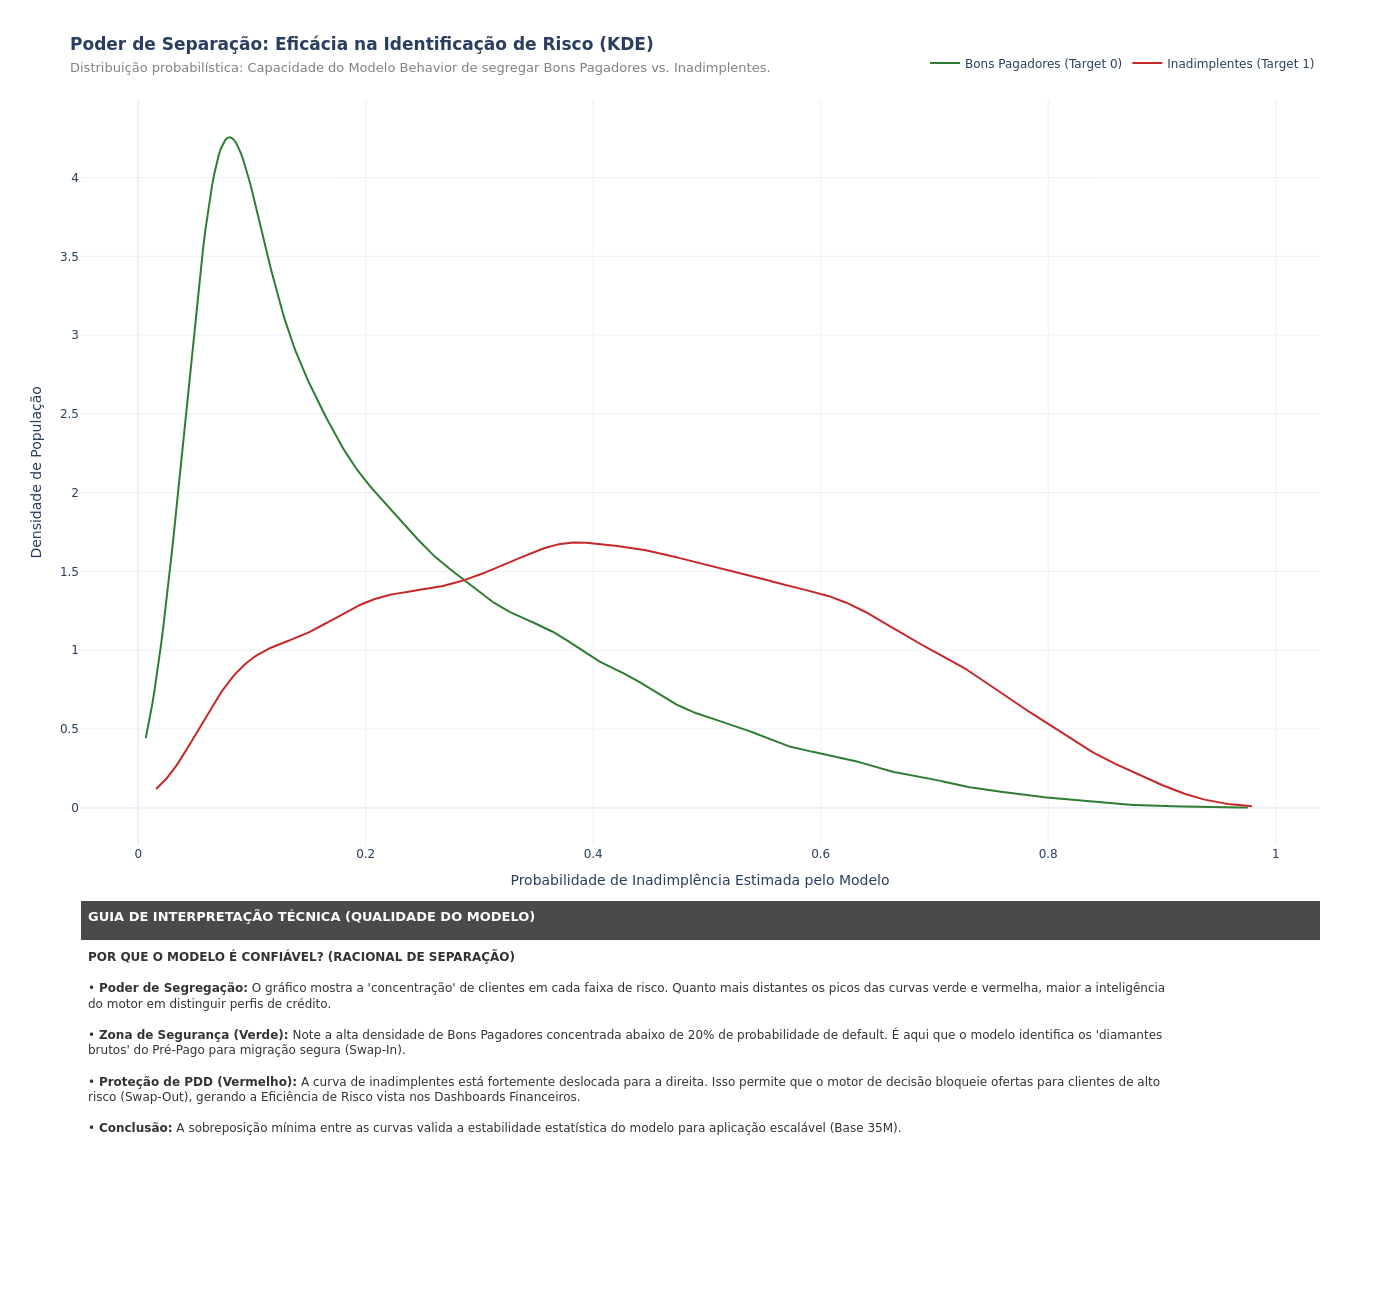

In [8]:
# ---------------------------------------------------------
# DENSIDADE DE SEPARAÇÃO: EFICÁCIA NA IDENTIFICAÇÃO DE RISCO
# ---------------------------------------------------------

print("⚙️ Gerando Curvas de Densidade Probabilística (KDE)...")

hist_data = [
    df_swap[df_swap['target'] == 0]['prob_modelo'], 
    df_swap[df_swap['target'] == 1]['prob_modelo']
]
group_labels = ['Bons Pagadores (Target 0)', 'Inadimplentes (Target 1)']
colors = ['#2E7D32', '#C62828'] 

fig = make_subplots(
    rows=2, cols=1,
    vertical_spacing=0.05,
    row_heights=[0.7, 0.3],
    specs=[[{"type": "xy"}], [{"type": "table"}]]
)

fig_kde = ff.create_distplot(hist_data, group_labels, show_hist=False, colors=colors)

for trace in fig_kde.data:
    fig.add_trace(trace, row=1, col=1)

explica_separacao = (
    "<b>POR QUE O MODELO É CONFIÁVEL? (RACIONAL DE SEPARAÇÃO)</b><br><br>"
    "• <b>Poder de Segregação:</b> O gráfico mostra a 'concentração' de clientes em cada faixa de risco. "
    "Quanto mais distantes os picos das curvas verde e vermelha, maior a inteligência do motor em distinguir perfis de crédito.<br><br>"
    "• <b>Zona de Segurança (Verde):</b> Note a alta densidade de Bons Pagadores concentrada abaixo de 20% de probabilidade de default. "
    "É aqui que o modelo identifica os 'diamantes brutos' do Pré-Pago para migração segura (Swap-In).<br><br>"
    "• <b>Proteção de PDD (Vermelho):</b> A curva de inadimplentes está fortemente deslocada para a direita. Isso permite que o motor de decisão bloqueie "
    "ofertas para clientes de alto risco (Swap-Out), gerando a Eficiência de Risco vista nos Dashboards Financeiros.<br><br>"
    f"• <b>Conclusão:</b> A sobreposição mínima entre as curvas valida a estabilidade estatística do modelo para aplicação escalável (Base {BASE_TOTAL_CLARO/1000000:.0f}M)."
)

def wrap_paragraphs(text, width=100):
    paragrafos = text.split('<br><br>')
    paragrafos_wrapped = []
    for p in paragrafos:
        linhas = textwrap.wrap(p, width=width)
        paragrafos_wrapped.append('<br>'.join(linhas))
    return '<br><br>'.join(paragrafos_wrapped)

texto_formatado = wrap_paragraphs(explica_separacao, width=180)
altura_celula = texto_formatado.count('<br>') * 26 + 50

fig.add_trace(go.Table(
    header=dict(
        values=["<b>GUIA DE INTERPRETAÇÃO TÉCNICA (QUALIDADE DO MODELO)</b>"],
        fill_color='#4A4A4A', align='left', font=dict(color='white', size=13), height=40
    ),
    cells=dict(
        values=[[texto_formatado]],
        fill_color='#FFFFFF', align='left', font=dict(size=12, color='#333333'),
        height=altura_celula
    )
), row=2, col=1)

fig.update_layout(
    title="<b>Poder de Separação: Eficácia na Identificação de Risco (KDE)</b><br><span style='font-size:13px;color:gray'>Distribuição probabilística: Capacidade do Modelo Behavior de segregar Bons Pagadores vs. Inadimplentes.</span>",
    height=1300, width=1400,
    xaxis_title="Probabilidade de Inadimplência Estimada pelo Modelo",
    yaxis_title="Densidade de População",
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    paper_bgcolor='white',
    plot_bgcolor='rgba(0,0,0,0)'
)

fig.write_image(FIGURES_DIR / '02_poder_separacao_v1.png', scale=2)
fig.show(renderer='png')

⚙️ Executando Motor Financeiro (Visão LTV) | Conversão Calibrada: 3.00%


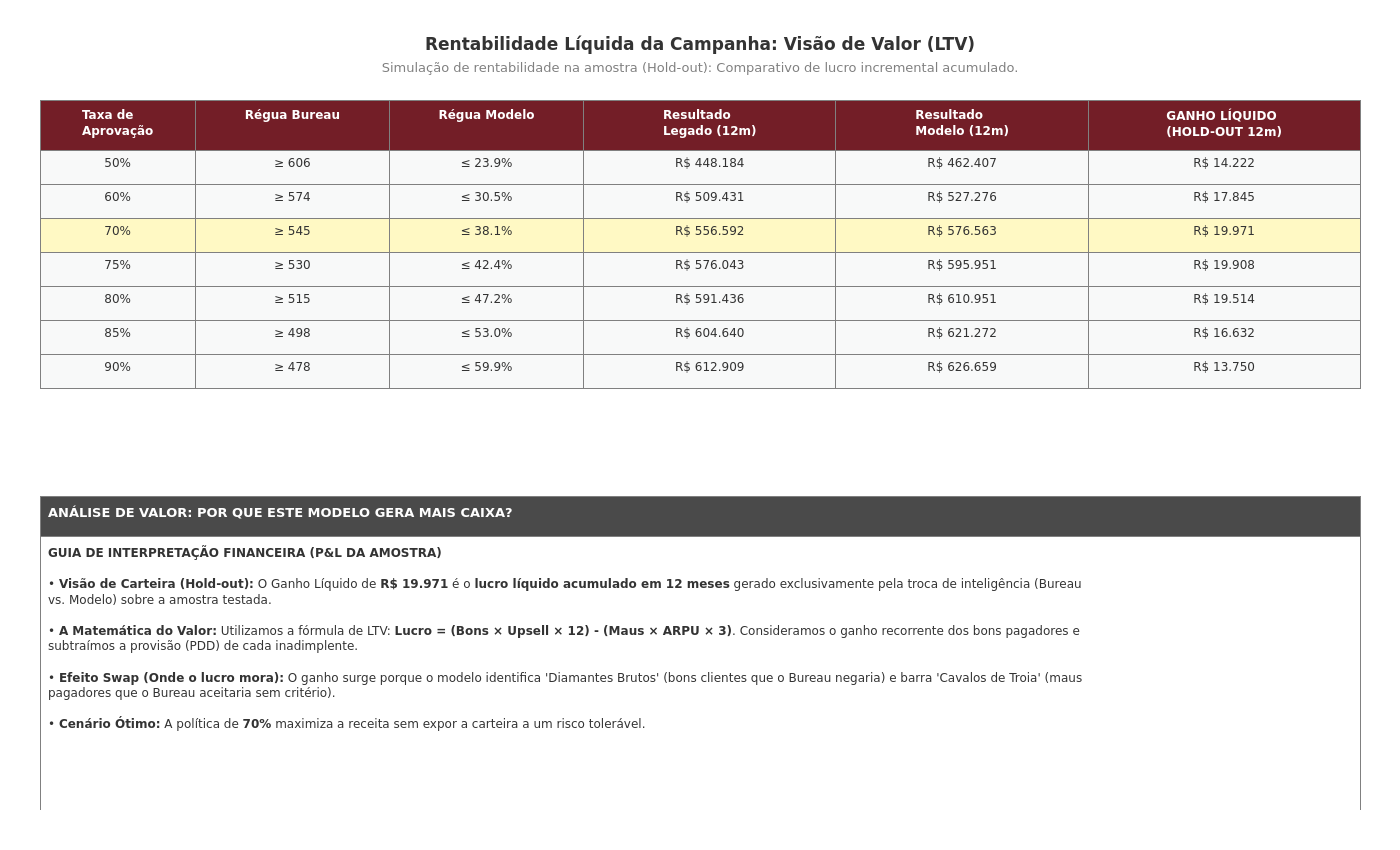

In [9]:
# ---------------------------------------------------------
# MOTOR DE DECISÃO E RENTABILIDADE LÍQUIDA (AMOSTRA)
# ---------------------------------------------------------


print(f"⚙️ Executando Motor Financeiro (Visão LTV) | Conversão Calibrada: {TAXA_CONVERSAO_AMOSTRA:.2%}")

df_swap['rank_bur'] = df_swap['bur_score_02'].rank(method='first', ascending=False)
df_swap['rank_mod'] = df_swap['prob_modelo'].rank(method='first', ascending=True)

cenarios_biz = []
percentis_alvo = [50, 60, 70, 75, 80, 85, 90]
total_clientes = len(df_swap)

for pct in percentis_alvo:
    n_aprovados = int(total_clientes * (pct/100))
    
    mask_bur = df_swap['rank_bur'] <= n_aprovados
    mask_mod = df_swap['rank_mod'] <= n_aprovados
    
    swap_in = (~mask_bur) & mask_mod
    swap_out = mask_bur & (~mask_mod)
    
    cutoff_val_bur = df_swap.loc[df_swap['rank_bur'] == n_aprovados, 'bur_score_02'].values[0]
    cutoff_val_mod = df_swap.loc[df_swap['rank_mod'] == n_aprovados, 'prob_modelo'].values[0]
    
    bur_goods = mask_bur.sum() - df_swap.loc[mask_bur, 'target'].sum()
    bur_bads = df_swap.loc[mask_bur, 'target'].sum()
    rec_legado = (bur_goods * TAXA_CONVERSAO_AMOSTRA * UPSELL * MESES_LTV) - \
                 (bur_bads * TAXA_CONVERSAO_AMOSTRA * ARPU_CONTROLE * MESES_INADIMPLENCIA)
    
    mod_goods = mask_mod.sum() - df_swap.loc[mask_mod, 'target'].sum()
    mod_bads = df_swap.loc[mask_mod, 'target'].sum()
    rec_modelo = (mod_goods * TAXA_CONVERSAO_AMOSTRA * UPSELL * MESES_LTV) - \
                 (mod_bads * TAXA_CONVERSAO_AMOSTRA * ARPU_CONTROLE * MESES_INADIMPLENCIA)
    
    cenarios_biz.append({
        'Taxa Aprovação': f"{pct}%",
        'Corte_Legado': cutoff_val_bur,
        'Corte_Modelo': cutoff_val_mod,
        'Receita_Legado': rec_legado,
        'Receita_Modelo': rec_modelo,
        'Impacto_Incremental': rec_modelo - rec_legado,
        'Vol_Swap_In': swap_in.sum(),
        'Vol_Swap_Out': swap_out.sum()
    })

df_biz = pd.DataFrame(cenarios_biz)

idx_otimo = df_biz['Impacto_Incremental'].idxmax()
taxa_campea = df_biz.loc[idx_otimo, 'Taxa Aprovação']

def format_moeda_br(v):
    return f"R$ {v:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.')

fig = make_subplots(
    rows=2, cols=1, 
    vertical_spacing=0.02, 
    row_heights=[0.55, 0.45], 
    specs=[[{"type": "table"}], [{"type": "table"}]]
)

row_colors = ['#F8F9F9'] * len(df_biz)
row_colors[idx_otimo] = '#FFF9C4' 

fig.add_trace(go.Table(
    columnwidth=[0.8, 1, 1, 1.3, 1.3, 1.4],
    header=dict(
        values=["<b>Taxa de<br>Aprovação</b>", "<b>Régua Bureau</b>", "<b>Régua Modelo</b>", "<b>Resultado<br>Legado (12m)</b>", "<b>Resultado<br>Modelo (12m)</b>", "<b>GANHO LÍQUIDO<br>(HOLD-OUT 12m)</b>"],
        fill_color='#731E27', align='center', font=dict(color='white', size=12), height=50
    ),
    cells=dict(
        values=[
            df_biz['Taxa Aprovação'], 
            df_biz['Corte_Legado'].apply(lambda x: f"≥ {x:.0f}"), 
            df_biz['Corte_Modelo'].apply(lambda x: f"≤ {x*100:.1f}%"),
            df_biz['Receita_Legado'].apply(format_moeda_br),
            df_biz['Receita_Modelo'].apply(format_moeda_br),
            df_biz['Impacto_Incremental'].apply(format_moeda_br)
        ],
        fill_color=[row_colors]*6, align='center', font=dict(size=12), height=34
    )
), row=1, col=1)

racional_executivo = (
    "<b>GUIA DE INTERPRETAÇÃO FINANCEIRA (P&L DA AMOSTRA)</b><br><br>"
    f"• <b>Visão de Carteira (Hold-out):</b> O Ganho Líquido de <b>{format_moeda_br(df_biz.loc[idx_otimo, 'Impacto_Incremental'])}</b> "
    f"é o <b>lucro líquido acumulado em {MESES_LTV} meses</b> gerado exclusivamente pela troca de inteligência (Bureau vs. Modelo) sobre a amostra testada.<br><br>"
    f"• <b>A Matemática do Valor:</b> Utilizamos a fórmula de LTV: "
    f"<b>Lucro = (Bons × Upsell × {MESES_LTV}) - (Maus × ARPU × {MESES_INADIMPLENCIA})</b>. "
    f"Consideramos o ganho recorrente dos bons pagadores e subtraímos a provisão (PDD) de cada inadimplente.<br><br>"
    f"• <b>Efeito Swap (Onde o lucro mora):</b> O ganho surge porque o modelo identifica 'Diamantes Brutos' (bons clientes que o Bureau negaria) "
    f"e barra 'Cavalos de Troia' (maus pagadores que o Bureau aceitaria sem critério).<br><br>"
    f"• <b>Cenário Ótimo:</b> A política de <b>{taxa_campea}</b> maximiza a receita sem expor a carteira a um risco tolerável."
)

def wrap_paragraphs(text, width=180):
    paragrafos = text.split('<br><br>')
    paragrafos_wrapped = []
    for p in paragrafos:
        linhas = textwrap.wrap(p, width=width)
        paragrafos_wrapped.append('<br>'.join(linhas))
    return '<br><br>'.join(paragrafos_wrapped)

texto_formatado = wrap_paragraphs(racional_executivo, width=180)
altura_celula = texto_formatado.count('<br>') * 26 + 60

fig.add_trace(go.Table(
    header=dict(
        values=["<b>ANÁLISE DE VALOR: POR QUE ESTE MODELO GERA MAIS CAIXA?</b>"],
        fill_color='#4A4A4A', align='left', font=dict(color='white', size=13), height=40
    ),
    cells=dict(
        values=[[texto_formatado]],
        fill_color='#FFFFFF', align='left', font=dict(size=12, color='#333333'),
        height=altura_celula
    )
), row=2, col=1)

fig.update_layout(
    title="<b>Rentabilidade Líquida da Campanha: Visão de Valor (LTV)</b><br><span style='font-size:13px;color:gray'>Simulação de rentabilidade na amostra (Hold-out): Comparativo de lucro incremental acumulado.</span>",
    margin=dict(l=40, r=40, t=100, b=40), height=850, width=1400, paper_bgcolor='white'
)

fig.write_image(FIGURES_DIR / '03_retabilidade_liquida_amostra_v1.png', scale=2)
fig.show(renderer='png')

🚀 Gerando Comparativo de EBITDA Nacional: Legado vs. SQUAD 03...


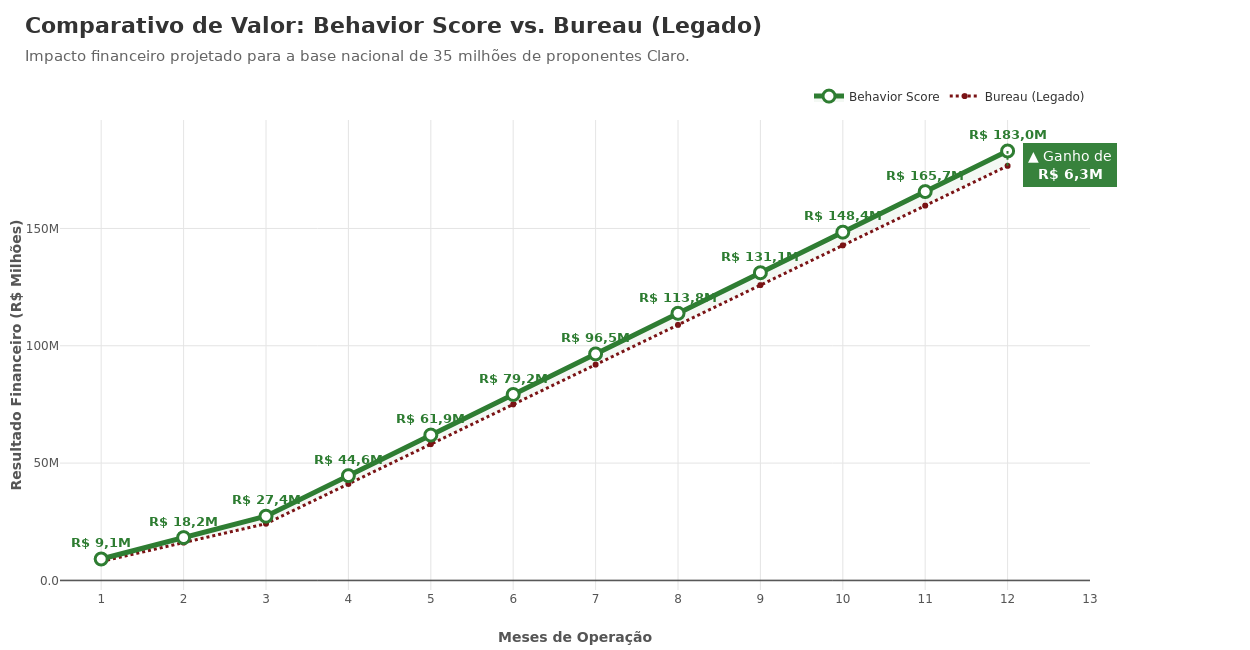

In [10]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# ---------------------------------------------------------
# 1. PARAMETRIZAÇÃO NACIONAL (EXTRAPOLAÇÃO 35M)
# ---------------------------------------------------------
print("🚀 Gerando Comparativo de EBITDA Nacional: Legado vs. SQUAD 03...")

fator_escala_nacional = 35_000_000 / len(df_swap)
conversao_meta = 0.03 

def format_moeda_milhoes(v):
    return f"R$ {v/1_000_000:.1f}M".replace('.', ',')

taxa_aprovacao = 0.70 

mask_mod = df_swap['rank_mod'] <= int(len(df_swap) * taxa_aprovacao)
mod_goods_nac = (mask_mod.sum() - df_swap.loc[mask_mod, 'target'].sum()) * fator_escala_nacional * conversao_meta
mod_bads_nac = df_swap.loc[mask_mod, 'target'].sum() * fator_escala_nacional * conversao_meta

mask_bur = df_swap['rank_bur'] <= int(len(df_swap) * taxa_aprovacao)
bur_goods_nac = (mask_bur.sum() - df_swap.loc[mask_bur, 'target'].sum()) * fator_escala_nacional * conversao_meta
bur_bads_nac = df_swap.loc[mask_bur, 'target'].sum() * fator_escala_nacional * conversao_meta

meses = np.arange(1, 13)
caixa_modelo, caixa_bureau = [], []

for m in meses:
    pdd_m = min(m, MESES_INADIMPLENCIA) / MESES_INADIMPLENCIA
    
    val_mod = (mod_goods_nac * UPSELL * m) - (mod_bads_nac * ARPU_CONTROLE * MESES_INADIMPLENCIA * pdd_m)
    val_bur = (bur_goods_nac * UPSELL * m) - (bur_bads_nac * ARPU_CONTROLE * MESES_INADIMPLENCIA * pdd_m)
    
    caixa_modelo.append(val_mod)
    caixa_bureau.append(val_bur)

# ---------------------------------------------------------
# 3. CONSTRUÇÃO DO VISUAL 
# ---------------------------------------------------------
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=meses, y=caixa_bureau,
    name='Bureau (Legado)',
    line=dict(color='#7A1315', width=3, dash='dot'),
    fill=None
))

fig.add_trace(go.Scatter(
    x=meses, y=caixa_modelo,
    name='Behavior Score',
    line=dict(color='#2E7D32', width=5),
    fill='tonexty', 
    fillcolor='rgba(46, 125, 50, 0.05)', 
    mode='lines+markers+text',
    text=[format_moeda_milhoes(v) for v in caixa_modelo],
    textposition="top center",
    textfont=dict(size=13, color='#2E7D32', family="Arial", weight="bold"),
    marker=dict(size=12, symbol='circle', color='white', line=dict(color='#2E7D32', width=3))
))

fig.add_hline(y=0, line_dash="solid", line_color="#555555", opacity=0.5)

# ---------------------------------------------------------
# 4. REFINAMENTO DE LAYOUT 
# ---------------------------------------------------------
ganho_final = caixa_modelo[-1] - caixa_bureau[-1]

fig.update_layout(
    title=dict(
        text=f"<b>Comparativo de Valor: Behavior Score vs. Bureau (Legado)</b><br><span style='font-size:15px;color:#666666'>Impacto financeiro projetado para a base nacional de 35 milhões de proponentes Claro.</span>",
        x=0.02, y=0.95, font=dict(size=22, color='#333333', family="Arial")
    ),
    height=650, width=1250,
    plot_bgcolor='rgba(0,0,0,0)', paper_bgcolor='rgba(0,0,0,0)',
    margin=dict(t=120, b=60, l=60, r=160), 
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1, font=dict(color='#333333')),
    showlegend=True
)

fig.update_xaxes(
    title_text="Meses de Operação", 
    title_font=dict(color="#555555", weight='bold'),
    tickfont=dict(color="#555555"),
    tickmode='linear', range=[0.5, 13], 
    showgrid=True, gridcolor='#E5E5E5'
)

fig.update_yaxes(
    title_text="Resultado Financeiro (R$ Milhões)", 
    title_font=dict(color="#555555", weight='bold'),
    tickfont=dict(color="#555555"),
    showgrid=True, gridcolor='#E5E5E5', 
    tickformat=".2s"
)

# ---------------------------------------------------------
# 5. ANOTAÇÃO (DELTA PILL)
# ---------------------------------------------------------
fig.add_shape(
    type="line", x0=12, x1=12, y0=caixa_bureau[-1], y1=caixa_modelo[-1],
    line=dict(color="#2E7D32", width=2, dash="dot")
)

fig.add_annotation(
    x=12, y=(caixa_modelo[-1] + caixa_bureau[-1])/2,
    text=f"▲ Ganho de<br><b>{format_moeda_milhoes(ganho_final)}</b>",
    showarrow=False,
    xanchor="left",
    xshift=15, 
    yshift=-7,
    font=dict(color="white", size=14, family="Arial"),
    bgcolor="#2E7D32", 
    bordercolor="#2E7D32", 
    borderpad=4,
    opacity=0.95
)

fig.write_image(FIGURES_DIR / '04_receita_upsell_ppt.png', scale=3)
fig.show(renderer='png')

⚙️ Gerando Curva de Custo do Erro (Refinamento Executivo 35M)...


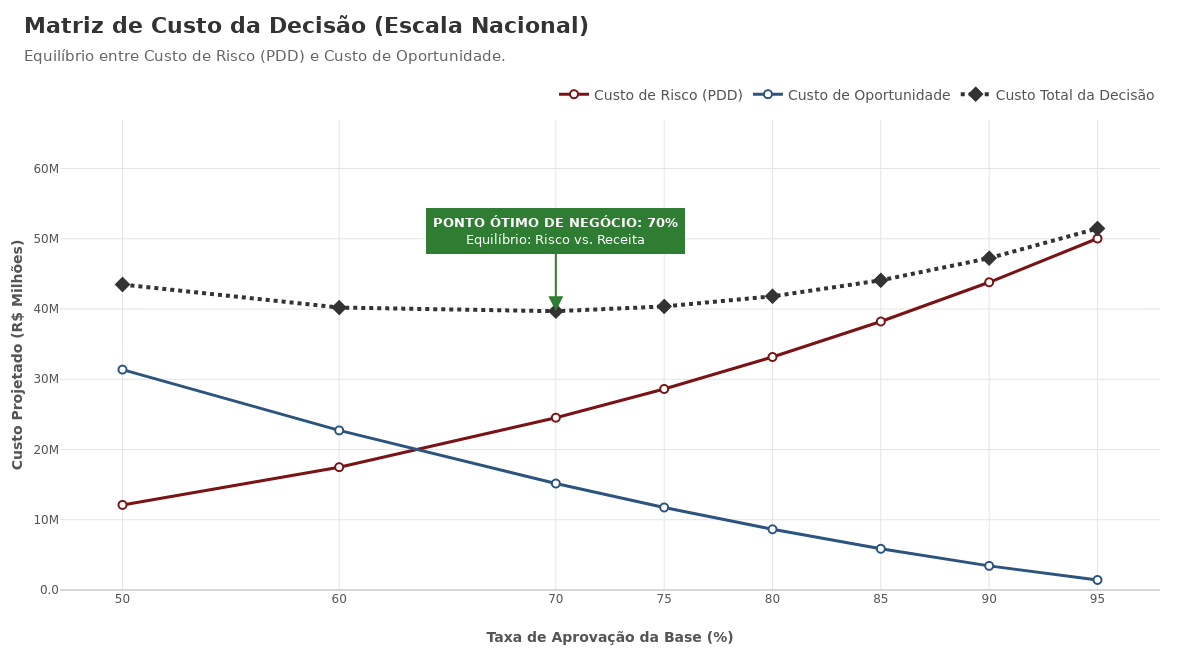

In [11]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# ---------------------------------------------------------
# 1. CÁLCULO DOS CUSTOS DE ERRO (TRADE-OFF) - ESCALA NACIONAL
# ---------------------------------------------------------
print("⚙️ Gerando Curva de Custo do Erro (Refinamento Executivo 35M)...")

MESES_LTV_GRAFICO = 4
fator_escala = 35_000_000 / len(df_swap)

def format_moeda_milhoes(v):
    return f"R$ {v/1_000_000:.1f}M".replace('.', ',')

cenarios_custo = []
percentis_alvo = [50, 60, 70, 75, 80, 85, 90, 95]

for pct in percentis_alvo:
    n_aprovados = int(len(df_swap) * (pct/100))
    mask_mod = df_swap['rank_mod'] <= n_aprovados
    
    fp_vol = df_swap.loc[mask_mod, 'target'].sum() * fator_escala * TAXA_CONVERSAO_META
    custo_fp = fp_vol * ARPU_CONTROLE * MESES_INADIMPLENCIA
    
    # FN correto: apenas os BONS entre os rejeitados (quem realmente perdemos)
    rejeitados = df_swap.loc[~mask_mod]
    fn_vol = (len(rejeitados) - rejeitados['target'].sum()) * fator_escala * TAXA_CONVERSAO_META
    custo_fn = fn_vol * UPSELL * MESES_LTV_GRAFICO
    
    custo_total = custo_fp + custo_fn
    cenarios_custo.append({
        'Aprovação': pct,
        'Custo_Risco (FP)': custo_fp,
        'Custo_Oportunidade (FN)': custo_fn,
        'Custo_Total': custo_total
    })

df_custo = pd.DataFrame(cenarios_custo)

melhor_corte_idx = df_custo['Custo_Total'].idxmin()
melhor_corte_val = df_custo.loc[melhor_corte_idx, 'Aprovação']
menor_custo_y = df_custo.loc[melhor_corte_idx, 'Custo_Total']

# ---------------------------------------------------------
# 2. PALETA DE CORES E DEFINIÇÃO DO VISUAL
# ---------------------------------------------------------
cor_fp = '#7A1315'     
cor_fn = '#2B547E'     
cor_total = '#333333'  
cor_otimo = '#2E7D32'  

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_custo['Aprovação'], y=df_custo['Custo_Risco (FP)'],
    mode='lines+markers', name='Custo de Risco (PDD)',
    line=dict(color=cor_fp, width=3), 
    marker=dict(size=8, symbol='circle', color='white', line=dict(color=cor_fp, width=2))
))

fig.add_trace(go.Scatter(
    x=df_custo['Aprovação'], y=df_custo['Custo_Oportunidade (FN)'],
    mode='lines+markers', name='Custo de Oportunidade',
    line=dict(color=cor_fn, width=3), 
    marker=dict(size=8, symbol='circle', color='white', line=dict(color=cor_fn, width=2))
))

fig.add_trace(go.Scatter(
    x=df_custo['Aprovação'], y=df_custo['Custo_Total'],
    mode='lines+markers', name='Custo Total da Decisão',
    line=dict(color=cor_total, width=4, dash='dot'), 
    marker=dict(size=12, symbol='diamond', color=cor_total),
    cliponaxis=False 
))

fig.add_annotation(
    x=melhor_corte_val, 
    y=menor_custo_y, 
    text=f"<b>PONTO ÓTIMO DE NEGÓCIO: {melhor_corte_val}%</b><br>Equilíbrio: Risco vs. Receita",
    showarrow=True, 
    arrowhead=2, 
    arrowsize=1.5,
    arrowwidth=2,
    arrowcolor=cor_otimo,
    ax=0, ay=-80, # Seta vindo de cima
    font=dict(color="white", size=13, family="Arial"), 
    bgcolor=cor_otimo, 
    bordercolor=cor_otimo,
    borderpad=6
)

# ---------------------------------------------------------
# 4. REFINAMENTO DE LAYOUT
# ---------------------------------------------------------
fig.update_layout(
    title=dict(
        text="<b>Matriz de Custo da Decisão (Escala Nacional)</b><br><span style='font-size:15px;color:#666666'>Equilíbrio entre Custo de Risco (PDD) e Custo de Oportunidade.</span>",
        x=0.02, y=0.95, font=dict(size=22, color='#333333', family="Arial")
    ),
    height=650, 
    width=1200,
    plot_bgcolor='rgba(0,0,0,0)',   
    paper_bgcolor='rgba(0,0,0,0)',
    margin=dict(t=120, b=60, l=60, r=40),
    legend=dict(
        orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1,
        font=dict(size=14, color='#555555')
    ),
    hovermode="x unified"
)

fig.update_xaxes(
    title_text="Taxa de Aprovação da Base (%)",
    title_font=dict(size=14, color='#555555', weight='bold'),
    tickfont=dict(color='#555555'),
    tickvals=percentis_alvo, 
    showgrid=True, gridcolor='#E5E5E5', zeroline=False
)

fig.update_yaxes(
    title_text="Custo Projetado (R$ Milhões)",
    title_font=dict(size=14, color='#555555', weight='bold'),
    tickfont=dict(color='#555555'),
    showgrid=True, gridcolor='#E5E5E5', zeroline=True, zerolinecolor='#B0B0B0',
    range=[0, df_custo['Custo_Total'].max() * 1.3],
    tickformat=".2s"
)

fig.write_image(FIGURES_DIR / '05_custo_do_erro_ppt.png', scale=3)
fig.show(renderer='png')

In [12]:
mask_mod_70 = df_swap['rank_mod'] <= int(len(df_swap) * 0.70)
print(df_swap.loc[mask_mod_70, 'target'].mean())  # bad rate aprovados
print(df_swap.loc[~mask_mod_70, 'target'].mean()) # bad rate rejeitados

0.18859393421171958
0.5851092772286206


🚀 Gerando Dashboard Nacional (Extrapolação via Ranking Fair-Play)...


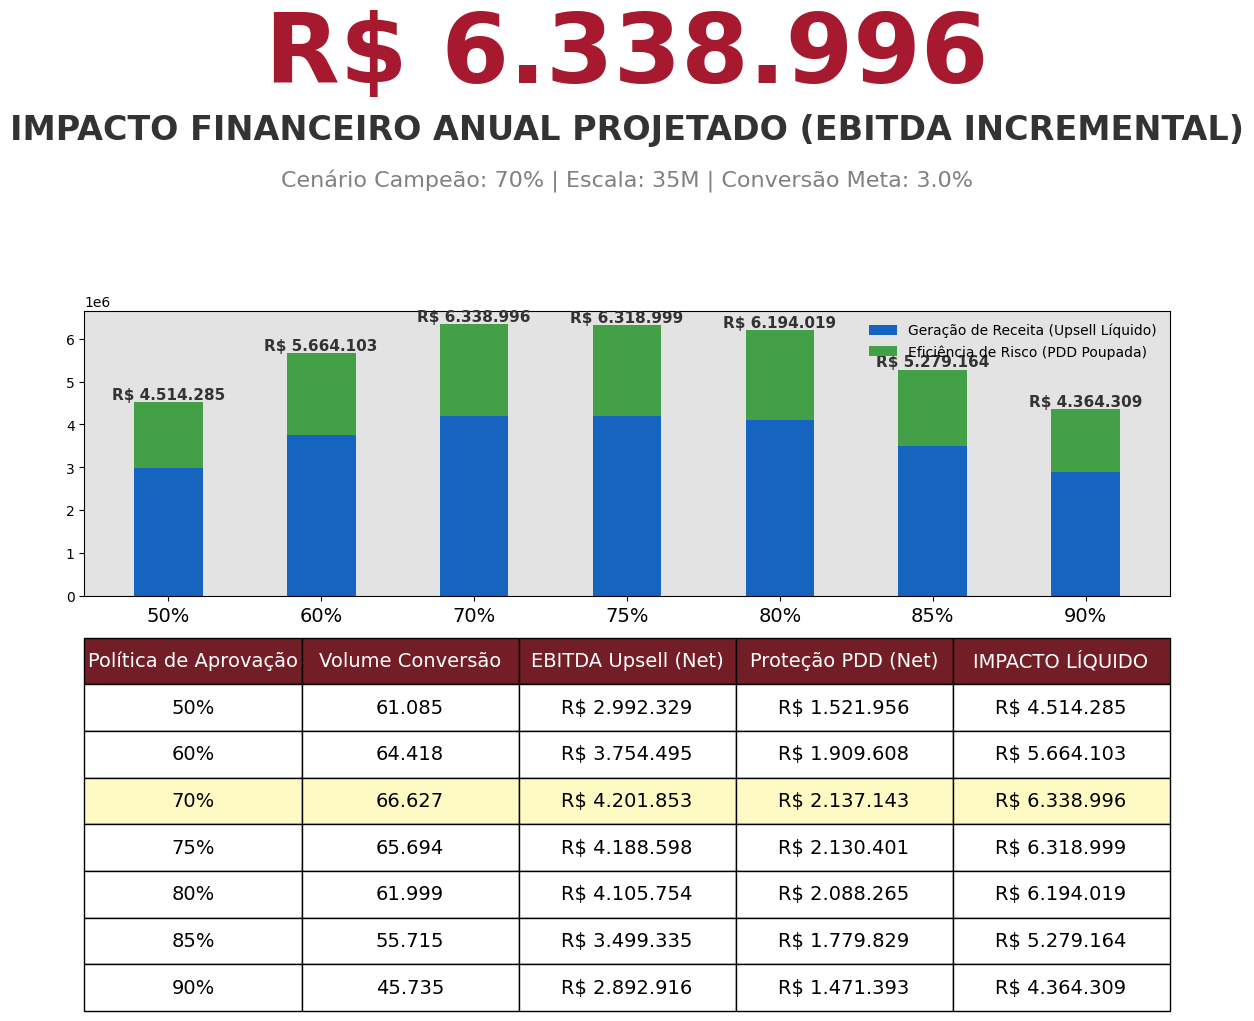

In [13]:
# ---------------------------------------------------------
# DASHBOARD EXECUTIVO NACIONAL (PROJEÇÃO DE EBITDA) - VALORES REAIS
# ---------------------------------------------------------


def format_moeda(v):
    return f"R$ {v:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.')

print("🚀 Gerando Dashboard Nacional (Extrapolação via Ranking Fair-Play)...")

n_amostra = len(df_swap)
fator_escala = BASE_TOTAL_CLARO / n_amostra

cenarios_nac = []
percentis_alvo = [50, 60, 70, 75, 80, 85, 90]

for pct in percentis_alvo:
    n_aprov = int(len(df_swap) * (pct/100)) 
    mask_bur = df_swap['rank_bur'] <= n_aprov
    mask_mod = df_swap['rank_mod'] <= n_aprov
    
    swap_in = (~mask_bur) & mask_mod
    swap_out = mask_bur & (~mask_mod)
    
    in_goods = swap_in.sum() - df_swap.loc[swap_in, 'target'].sum()
    in_bads = df_swap.loc[swap_in, 'target'].sum()
    out_goods = swap_out.sum() - df_swap.loc[swap_out, 'target'].sum()
    out_bads = df_swap.loc[swap_out, 'target'].sum()
    
    lucro_in_nac = ((in_goods * fator_escala * TAXA_CONVERSAO_META * UPSELL * MESES_LTV) - 
                    (in_bads * fator_escala * TAXA_CONVERSAO_META * ARPU_CONTROLE * MESES_INADIMPLENCIA))
    
    econ_out_nac = ((out_bads * fator_escala * TAXA_CONVERSAO_META * ARPU_CONTROLE * MESES_INADIMPLENCIA) - 
                    (out_goods * fator_escala * TAXA_CONVERSAO_META * UPSELL * MESES_LTV))
    
    total_real = lucro_in_nac + econ_out_nac
    
    upsell_net_nac = ((in_goods - out_goods) * fator_escala * TAXA_CONVERSAO_META * UPSELL * MESES_LTV)
    risco_net_nac = ((out_bads - in_bads) * fator_escala * TAXA_CONVERSAO_META * ARPU_CONTROLE * MESES_INADIMPLENCIA)

    cenarios_nac.append({
        'Aprovação': f"{pct}%",
        'Conv_Vol': (swap_in.sum() * fator_escala * TAXA_CONVERSAO_META),
        'Upsell_Net': upsell_net_nac,
        'PDD_Net': risco_net_nac,
        'Total_Real': total_real
    })

df_report_nac = pd.DataFrame(cenarios_nac)
idx_otimo = df_report_nac['Total_Real'].idxmax()
dados_otimos = df_report_nac.loc[idx_otimo]

fig = plt.figure(figsize=(14, 16), dpi=100, facecolor='white')
gs = GridSpec(4, 1, height_ratios=[0.8, 1.2, 1.2, 0.9], hspace=0.35)

ax0 = fig.add_subplot(gs[0]); ax0.axis('off')
ax0.text(0.5, 0.75, format_moeda(dados_otimos['Total_Real']), fontsize=70, color='#A6192E', ha='center', fontweight='bold')
ax0.text(0.5, 0.45, 'IMPACTO FINANCEIRO ANUAL PROJETADO (EBITDA INCREMENTAL)', fontsize=24, ha='center', color='#333333', fontweight='bold')
ax0.text(0.5, 0.20, f"Cenário Campeão: {dados_otimos['Aprovação']} | Escala: {BASE_TOTAL_CLARO/1000000:.0f}M | Conversão Meta: {TAXA_CONVERSAO_META:.1%}", fontsize=16, ha='center', color='gray')

ax1 = fig.add_subplot(gs[1])
x_pos = np.arange(len(df_report_nac['Aprovação']))
ax1.bar(x_pos, df_report_nac['Upsell_Net'], color='#1565C0', label='Geração de Receita (Upsell Líquido)', width=0.45)
ax1.bar(x_pos, df_report_nac['PDD_Net'], bottom=df_report_nac['Upsell_Net'], color='#43A047', label='Eficiência de Risco (PDD Poupada)', width=0.45)
ax1.set_xticks(x_pos); ax1.set_xticklabels(df_report_nac['Aprovação'], fontsize=14); ax1.legend(loc='upper right', frameon=False)

for i, total in enumerate(df_report_nac['Total_Real']):
    ax1.text(i, total, format_moeda(total), ha='center', fontweight='bold', fontsize=11, color='#333333', va='bottom')

ax2 = fig.add_subplot(gs[2]); ax2.axis('off')
table_data = [[r['Aprovação'], f"{r['Conv_Vol']:,.0f}".replace(',', '.'), format_moeda(r['Upsell_Net']), format_moeda(r['PDD_Net']), format_moeda(r['Total_Real'])] for _, r in df_report_nac.iterrows()]
tbl = ax2.table(cellText=table_data, colLabels=['Política de Aprovação', 'Volume Conversão', 'EBITDA Upsell (Net)', 'Proteção PDD (Net)', 'IMPACTO LÍQUIDO'], loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(14); tbl.scale(1, 2.8)

for j in range(5):
    tbl[0, j].set_facecolor('#731E27'); tbl[0, j].get_text().set_color('white')
    tbl[idx_otimo + 1, j].set_facecolor('#FFF9C4')

plt.savefig(FIGURES_DIR / '06_ebitida_impacto_geral_v1.png', dpi=100)
plt.show()

⚙️ Gerando Waterfall de Conciliação Financeira (Bridge de EBITDA)...


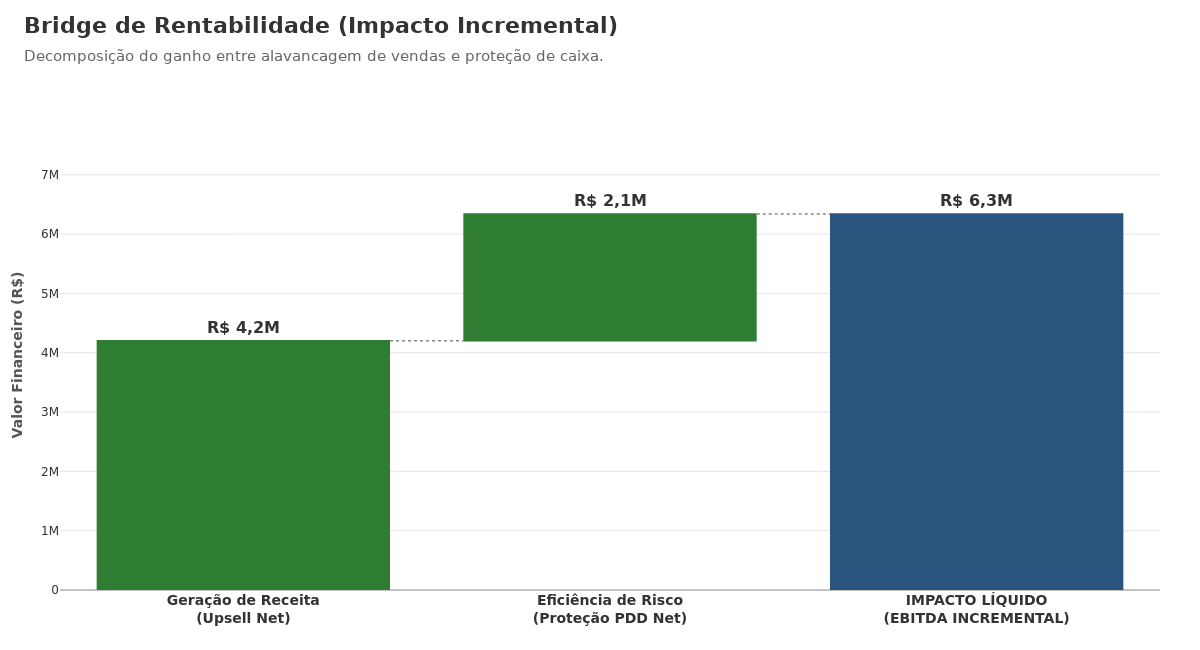

In [14]:
import pandas as pd
import plotly.graph_objects as go

# ---------------------------------------------------------
# CONCILIAÇÃO DE VALOR: BRIDGE DE EBITDA (NACIONAL)
# ---------------------------------------------------------
print("⚙️ Gerando Waterfall de Conciliação Financeira (Bridge de EBITDA)...")

def format_moeda_executivo(v):
    if abs(v) >= 1_000_000:
        return f"R$ {v/1_000_000:.1f}M".replace('.', ',')
    else:
        return f"R$ {v/1_000:.0f}k".replace('.', ',')

total_final = dados_otimos['Total_Real']
upsell_net_final = dados_otimos['Upsell_Net']
pdd_net_final = dados_otimos['PDD_Net']

# ---------------------------------------------------------
# PALETA DE CORES DEFINITIVA
# ---------------------------------------------------------
cor_ganho = '#2E7D32'   
cor_perda = '#7A1315'   
cor_total = '#2B547E'   

# ---------------------------------------------------------
# CONSTRUÇÃO DO VISUAL WATERFALL
# ---------------------------------------------------------
fig = go.Figure(go.Waterfall(
    name="EBITDA Bridge", 
    orientation="v",
    measure=["relative", "relative", "total"],
    x=[
        "Geração de Receita<br>(Upsell Net)", 
        "Eficiência de Risco<br>(Proteção PDD Net)", 
        "<b>IMPACTO LÍQUIDO<br>(EBITDA INCREMENTAL)</b>"
    ],
    y=[upsell_net_final, pdd_net_final, 0],
    text=[
        format_moeda_executivo(upsell_net_final), 
        format_moeda_executivo(pdd_net_final), 
        f"<b>{format_moeda_executivo(total_final)}</b>"
    ],
    textposition="outside",
    textfont=dict(size=16, family="Arial", weight="bold"),
    
    connector={"line": {"color": "#888888", "width": 1.5, "dash": "dot"}},
    
    increasing={"marker": {"color": cor_ganho}}, 
    decreasing={"marker": {"color": cor_perda}}, 
    totals={"marker": {"color": cor_total}},
    
    cliponaxis=False
))

# ---------------------------------------------------------
# REFINAMENTO EXECUTIVO DO LAYOUT
# ---------------------------------------------------------
y_max = max(upsell_net_final + pdd_net_final, total_final) * 1.25

fig.update_layout(
    title=dict(
        text=f"<b>Bridge de Rentabilidade (Impacto Incremental)</b><br><span style='font-size:15px;color:#666666'>Decomposição do ganho entre alavancagem de vendas e proteção de caixa.</span>",
        x=0.02, y=0.95, font=dict(size=22, color='#333333', family="Arial")
    ),
    height=650, 
    width=1200,
    plot_bgcolor='rgba(0,0,0,0)',   
    paper_bgcolor='rgba(0,0,0,0)',
    margin=dict(t=120, b=60, l=60, r=40),
    showlegend=False
)

fig.update_xaxes(
    tickfont=dict(size=14, color='#333333', weight='bold'),
    showgrid=False, zeroline=False
)

fig.update_yaxes(
    title_text="Valor Financeiro (R$)",
    title_font=dict(size=14, color='#555555', weight='bold'),
    showgrid=True, gridcolor='#E5E5E5', 
    zeroline=True, zerolinecolor='#888888',
    range=[0, y_max]
)

fig.write_image(FIGURES_DIR / '07_conciliacao_financeira_ppt.png', scale=3)
fig.show(renderer='png')

⚡ Executando Stress Test de Resiliência Financeira (Cenário Nacional)...


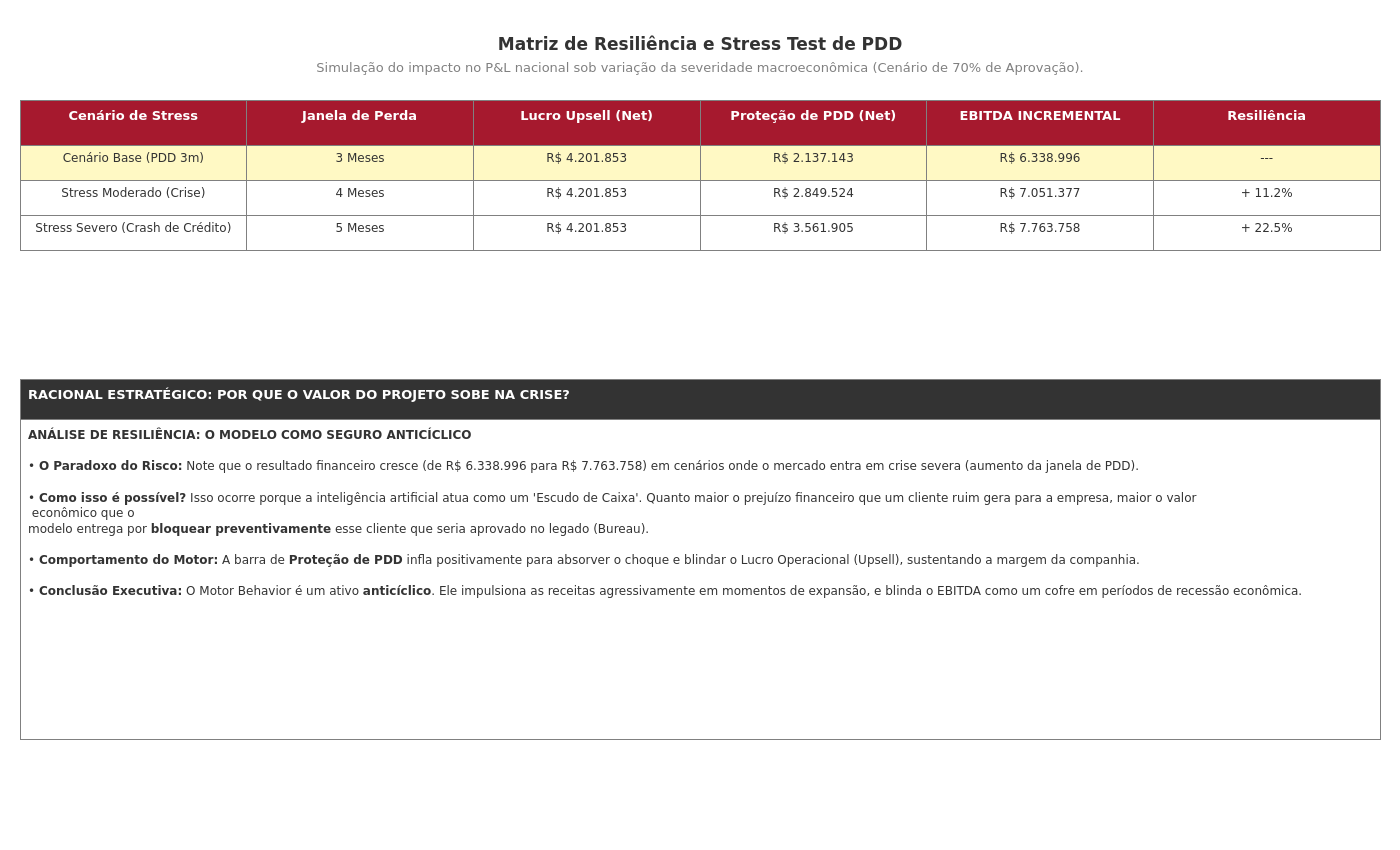

In [15]:
# ---------------------------------------------------------
# MATRIZ DE RESILIÊNCIA E STRESS TEST DE PDD
# ---------------------------------------------------------


def format_moeda(v):
    return f"R$ {v:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.')

print("⚡ Executando Stress Test de Resiliência Financeira (Cenário Nacional)...")

taxa_aprov_num = float(taxa_campea.replace('%', '')) / 100
n_aprovados = int(len(df_swap) * taxa_aprov_num)

mask_bur = df_swap['rank_bur'] <= n_aprovados
mask_mod = df_swap['rank_mod'] <= n_aprovados

swap_in = (~mask_bur) & mask_mod
swap_out = mask_bur & (~mask_mod)

s_in_goods = swap_in.sum() - df_swap.loc[swap_in, 'target'].sum()
s_in_bads = df_swap.loc[swap_in, 'target'].sum()
s_out_goods = swap_out.sum() - df_swap.loc[swap_out, 'target'].sum()
s_out_bads = df_swap.loc[swap_out, 'target'].sum()

cenarios_pdd = [
    {'Meses': MESES_INADIMPLENCIA, 'Descricao': f'Cenário Base (PDD {MESES_INADIMPLENCIA}m)'},
    {'Meses': MESES_INADIMPLENCIA + 1, 'Descricao': 'Stress Moderado (Crise)'},
    {'Meses': MESES_INADIMPLENCIA + 2, 'Descricao': 'Stress Severo (Crash de Crédito)'}
]

resultados_sensibilidade = []

upsell_net_base = ((s_in_goods - s_out_goods) * fator_escala * TAXA_CONVERSAO_META * UPSELL * MESES_LTV)

for cenario in cenarios_pdd:
    m_loss = cenario['Meses']
    
    lucro_in = ((s_in_goods * fator_escala * TAXA_CONVERSAO_META * UPSELL * MESES_LTV) - 
                (s_in_bads * fator_escala * TAXA_CONVERSAO_META * ARPU_CONTROLE * m_loss))
    
    prot_out = ((s_out_bads * fator_escala * TAXA_CONVERSAO_META * ARPU_CONTROLE * m_loss) - 
                (s_out_goods * fator_escala * TAXA_CONVERSAO_META * UPSELL * MESES_LTV))
    
    total_real = lucro_in + prot_out
    
    risco_net = ((s_out_bads - s_in_bads) * fator_escala * TAXA_CONVERSAO_META * ARPU_CONTROLE * m_loss)
    
    if cenario['Descricao'].startswith('Cenário Base'):
        base_real_st = total_real
        variacao = "---"
    else:
        pct_change = ((total_real / base_real_st) - 1) * 100
        variacao = f"+ {pct_change:.1f}%"
        
    resultados_sensibilidade.append({
        'Cenário de Stress': cenario['Descricao'],
        'Janela de Perda': f"{m_loss} Meses",
        'Lucro Upsell (Net)': format_moeda(upsell_net_base), 
        'Proteção de PDD': format_moeda(risco_net),       
        'EBITDA INCREMENTAL': format_moeda(total_real),
        'Ganho de Resiliência': variacao
    })
    
    if m_loss == cenarios_pdd[-1]['Meses']: stress_real_max = total_real

df_sens = pd.DataFrame(resultados_sensibilidade)

fig = make_subplots(
    rows=2, cols=1,
    vertical_spacing=0.05,
    row_heights=[0.35, 0.65],
    specs=[[{"type": "table"}], [{"type": "table"}]]
)

fig.add_trace(go.Table(
    header=dict(
        values=["<b>Cenário de Stress</b>", "<b>Janela de Perda</b>", "<b>Lucro Upsell (Net)</b>", "<b>Proteção de PDD (Net)</b>", "<b>EBITDA INCREMENTAL</b>", "<b>Resiliência</b>"],
        fill_color='#A6192E', align='center', font=dict(color='white', size=13), height=45
    ),
    cells=dict(
        values=[df_sens[c] for c in df_sens.columns],
        fill_color=[['#FFF9C4', '#FFFFFF', '#FFFFFF'] * len(df_sens)],
        align='center', font=dict(size=12), height=35
    )
), row=1, col=1)

def format_moeda_html(v):
    # Usa o código HTML &#36; para o cifrão, evitando o gatilho do LaTeX no Plotly
    return f"R&#36; {v:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.')

racional_stress = (
    "<b>ANÁLISE DE RESILIÊNCIA: O MODELO COMO SEGURO ANTICÍCLICO</b><br><br>"
    f"• <b>O Paradoxo do Risco:</b> Note que o resultado financeiro cresce (de {format_moeda_html(base_real_st)} para {format_moeda_html(stress_real_max)}) "
    "em cenários onde o mercado entra em crise severa (aumento da janela de PDD).<br><br>"
    "• <b>Como isso é possível?</b> Isso ocorre porque a inteligência artificial atua como um 'Escudo de Caixa'. Quanto maior o prejuízo financeiro "
    "que um cliente ruim gera para a empresa, maior o valor<br> econômico que o modelo entrega por <b>bloquear preventivamente</b> esse cliente "
    "que seria aprovado no legado (Bureau).<br><br>"
    "• <b>Comportamento do Motor:</b> A barra de <b>Proteção de PDD</b> infla positivamente para absorver o choque e blindar o "
    "Lucro Operacional (Upsell), sustentando a margem da companhia.<br><br>"
    "• <b>Conclusão Executiva:</b> O Motor Behavior é um ativo <b>anticíclico</b>. Ele impulsiona as receitas agressivamente em momentos de expansão, "
    "e blinda o EBITDA como um cofre em períodos de recessão econômica."
)

def wrap_paragraphs(text, width=100):
    paragrafos = text.split('<br><br>')
    paragrafos_wrapped = []
    for p in paragrafos:
        linhas = textwrap.wrap(p, width=width)
        paragrafos_wrapped.append('<br>'.join(linhas))
    return '<br><br>'.join(paragrafos_wrapped)

texto_formatado = wrap_paragraphs(racional_stress, width=220)
altura_celula = texto_formatado.count('<br>') * 26 + 60

fig.add_trace(go.Table(
    header=dict(
        values=["<b>RACIONAL ESTRATÉGICO: POR QUE O VALOR DO PROJETO SOBE NA CRISE?</b>"],
        fill_color='#333333', align='left', font=dict(color='white', size=13), height=40
    ),
    cells=dict(
        values=[[texto_formatado]],
        fill_color='#FFFFFF', align='left', font=dict(size=12, color='#333333'),
        height=altura_celula
    )
), row=2, col=1)

fig.update_layout(
    title=f"<b>Matriz de Resiliência e Stress Test de PDD</b><br><span style='font-size:13px;color:gray'>Simulação do impacto no P&L nacional sob variação da severidade macroeconômica (Cenário de {taxa_campea} de Aprovação).</span>",
    margin=dict(l=20, r=20, t=100, b=20), height=850, width=1400, paper_bgcolor='white'
)

fig.write_image(FIGURES_DIR / '08_matriz_resiliencia_geral_v1.png', scale=2)
fig.show(renderer='png')

⚙️ Gerando Tierização Estratégica para Ações de CRM...


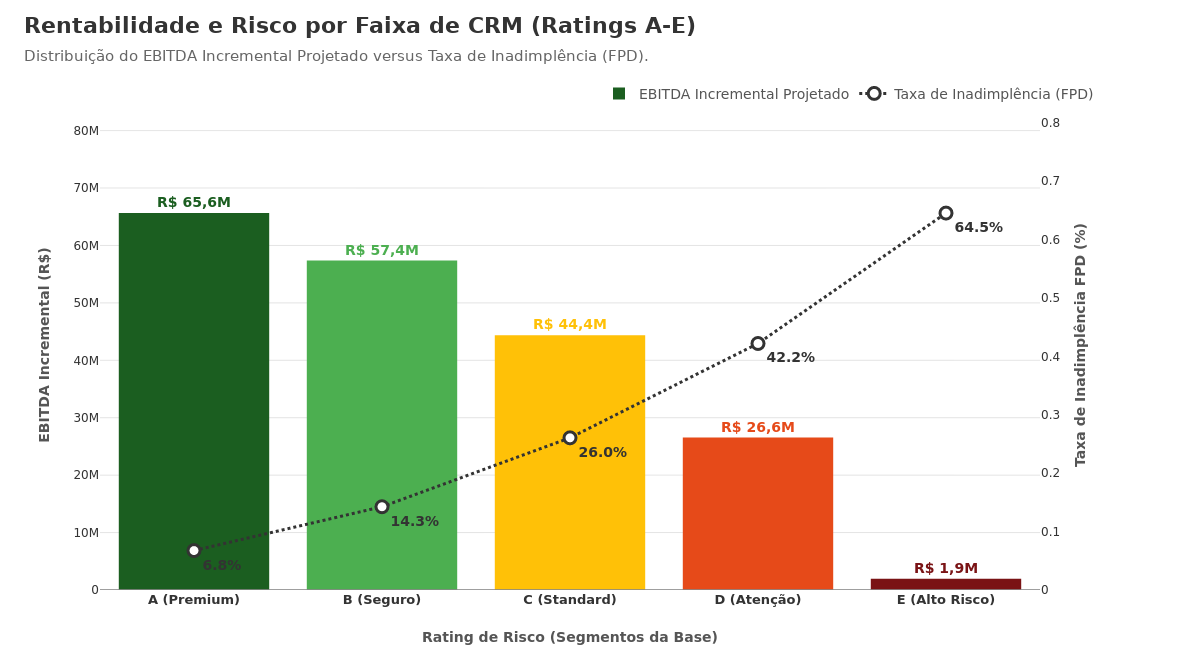

In [16]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ---------------------------------------------------------
# 1. CÁLCULO DA TIERIZAÇÃO (RATING A-E)
# ---------------------------------------------------------
print("⚙️ Gerando Tierização Estratégica para Ações de CRM...")

def format_moeda_html(v):
    if v >= 1_000_000:
        return f"R$ {v/1_000_000:.1f}M".replace('.', ',')
    elif v <= -1_000_000:
        return f"-R$ {abs(v)/1_000_000:.1f}M".replace('.', ',')
    else:
        return f"R$ {v/1_000:.0f}k".replace('.', ',')

# Divide a base em 5 decis (Rating A até E) baseados na probabilidade do modelo
df_swap['rating_crm'] = pd.qcut(df_swap['prob_modelo'], q=5, labels=['A (Premium)', 'B (Seguro)', 'C (Standard)', 'D (Atenção)', 'E (Alto Risco)'])

analise_tier = df_swap.groupby('rating_crm').agg(
    Volume_CPFs=('prob_modelo', 'count'),
    Inadimplencia_FPD=('target', 'mean')
).reset_index()

# Escala os volumes e calcula a receita potencial por Tier
analise_tier['Vol_Nacional'] = analise_tier['Volume_CPFs'] * fator_escala * TAXA_CONVERSAO_META
analise_tier['EBITDA_Potencial'] = (analise_tier['Vol_Nacional'] * (1 - analise_tier['Inadimplencia_FPD']) * UPSELL * MESES_LTV) - \
                                   (analise_tier['Vol_Nacional'] * analise_tier['Inadimplencia_FPD'] * ARPU_CONTROLE * MESES_INADIMPLENCIA)

# ---------------------------------------------------------
# 2. PALETA DE CORES (SEMÁFORO CORPORATIVO)
# ---------------------------------------------------------
cores_tier = [
    '#1B5E20',  # Verde Escuro (A)
    '#4CAF50',  # Verde Claro (B)
    '#FFC107',  # Amarelo/Mostarda (C)
    '#E64A19',  # Laranja Queimado (D)
    '#7A1315'   # Bordô POD/Claro (E)
]
cor_linha_risco = '#333333' # Cinza Chumbo Escuro

# ---------------------------------------------------------
# 3. CONSTRUÇÃO DO VISUAL DE EIXO DUPLO (DUAL AXIS)
# ---------------------------------------------------------
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(go.Bar(
    x=analise_tier['rating_crm'], y=analise_tier['EBITDA_Potencial'],
    name="EBITDA Incremental Projetado",
    marker_color=cores_tier,
    text=[format_moeda_html(v) for v in analise_tier['EBITDA_Potencial']],
    textposition="outside",
    textfont=dict(size=14, color=cores_tier, weight="bold"),
    cliponaxis=False
), secondary_y=False)

fig.add_trace(go.Scatter(
    x=analise_tier['rating_crm'], y=analise_tier['Inadimplencia_FPD'],
    name="Taxa de Inadimplência (FPD)",
    mode="lines+markers+text",
    line=dict(color=cor_linha_risco, width=3, dash='dot'), 
    marker=dict(size=12, symbol='circle', color='white', line=dict(color=cor_linha_risco, width=3)),
    text=[f"{v:.1%}" for v in analise_tier['Inadimplencia_FPD']],
    textposition="bottom right",
    textfont=dict(size=14, color=cor_linha_risco, weight="bold"),
    cliponaxis=False
), secondary_y=True)

fig.add_hline(y=0, line_dash="solid", line_color="#888888", line_width=2, opacity=0.8, secondary_y=False)

# ---------------------------------------------------------
# 4. REFINAMENTO  DO LAYOUT
# ---------------------------------------------------------
y1_max = analise_tier['EBITDA_Potencial'].max() * 1.3
y1_min = 0
y2_max = analise_tier['Inadimplencia_FPD'].max() * 1.3

fig.update_layout(
    title=dict(
        text="<b>Rentabilidade e Risco por Faixa de CRM (Ratings A-E)</b><br><span style='font-size:15px;color:#666666'>Distribuição do EBITDA Incremental Projetado versus Taxa de Inadimplência (FPD).</span>",
        x=0.02, y=0.95, font=dict(size=22, color='#333333', family="Arial")
    ),
    height=650, 
    width=1200,
    plot_bgcolor='rgba(0,0,0,0)',   
    paper_bgcolor='rgba(0,0,0,0)',
    margin=dict(t=100, b=60, l=100, r=100),
    
    legend=dict(
        orientation="h", yanchor="bottom", y=0.98, xanchor="right", x=1,
        font=dict(size=14, color='#555555')
    ),
    barmode='group'
)

fig.update_xaxes(
    title_text="Rating de Risco (Segmentos da Base)",
    title_font=dict(size=14, color='#555555', weight='bold'),
    showgrid=False, zeroline=False,
    tickfont=dict(size=13, color='#333333', weight='bold')
)

fig.update_yaxes(
    title_text="EBITDA Incremental (R$)",
    title_font=dict(size=14, color='#555555', weight='bold'),
    showgrid=True, gridcolor='#E5E5E5', zeroline=False, 
    range=[y1_min, y1_max],
    secondary_y=False,
    title_standoff=20
)

fig.update_yaxes(
    title_text="Taxa de Inadimplência FPD (%)",
    title_font=dict(size=14, color='#555555', weight='bold'),
    showgrid=False, zeroline=False, 
    range=[0, y2_max],
    secondary_y=True
)

fig.write_image(FIGURES_DIR / '09_tierizacao_crm_ppt.png', scale=3)
fig.show(renderer='png')

In [17]:
analise_tier['EBITDA_Potencial'].sum()

np.float64(195864003.82434502)

⚙️ Gerando Análise de Sensibilidade: Elasticidade de Conversão de Vendas...


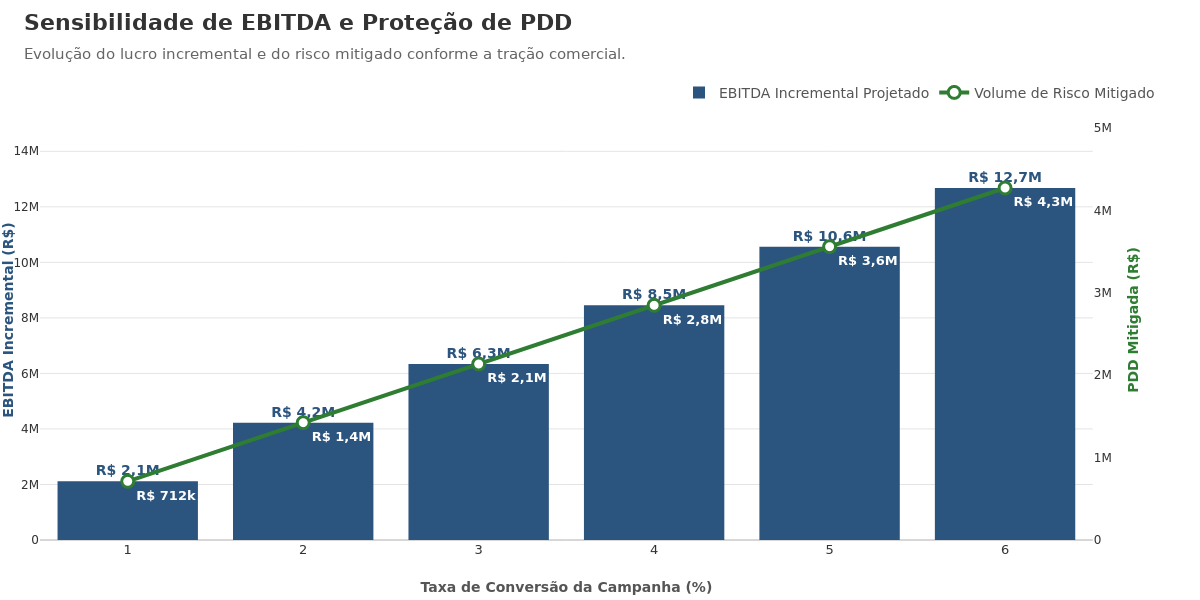

In [18]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ---------------------------------------------------------
# 1. CÁLCULO DA SENSIBILIDADE
# ---------------------------------------------------------
print("⚙️ Gerando Análise de Sensibilidade: Elasticidade de Conversão de Vendas...")

def format_moeda_html(v):
    if v >= 1_000_000:
        return f"R$ {v/1_000_000:.1f}M".replace('.', ',')
    else:
        return f"R$ {v/1_000:.0f}k".replace('.', ',')

taxa_aprov_num = float(taxa_campea.replace('%', '')) / 100
n_aprovados = int(len(df_swap) * taxa_aprov_num)

mask_mod = df_swap['rank_mod'] <= n_aprovados
mask_bur = df_swap['rank_bur'] <= n_aprovados
swap_in = (~mask_bur) & mask_mod
swap_out = mask_bur & (~mask_mod)

s_in_goods = swap_in.sum() - df_swap.loc[swap_in, 'target'].sum()
s_in_bads = df_swap.loc[swap_in, 'target'].sum()
s_out_goods = swap_out.sum() - df_swap.loc[swap_out, 'target'].sum()
s_out_bads = df_swap.loc[swap_out, 'target'].sum()

cenarios_conversao = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06] 
resultados_mkt = []

for conv in cenarios_conversao:
    upsell_net = ((s_in_goods - s_out_goods) * fator_escala * conv * UPSELL * MESES_LTV)
    risco_net = ((s_out_bads - s_in_bads) * fator_escala * conv * ARPU_CONTROLE * MESES_INADIMPLENCIA)
    ebitda_total = upsell_net + risco_net
    
    resultados_mkt.append({
        'Conversao': conv,
        'EBITDA_Total': ebitda_total,
        'Risco_Net': risco_net
    })

df_mkt = pd.DataFrame(resultados_mkt)

# ---------------------------------------------------------
# 2. PALETA DE CORES ATUALIZADA (O Alívio Visual)
# ---------------------------------------------------------
cor_ebitda = '#2B547E'  
cor_risco = '#2E7D32'   

# ---------------------------------------------------------
# 3. CONSTRUÇÃO DO VISUAL DE EIXO DUPLO (DUAL AXIS)
# ---------------------------------------------------------
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(go.Bar(
    x=[f"{v*100:.0f}%" for v in df_mkt['Conversao']], 
    y=df_mkt['EBITDA_Total'],
    name="EBITDA Incremental Projetado",
    marker_color=cor_ebitda,
    text=[format_moeda_html(v) for v in df_mkt['EBITDA_Total']],
    textposition="outside", 
    textfont=dict(size=14, color=cor_ebitda, weight="bold"),
    cliponaxis=False 
), secondary_y=False)

fig.add_trace(go.Scatter(
    x=[f"{v*100:.0f}%" for v in df_mkt['Conversao']], 
    y=df_mkt['Risco_Net'],
    name="Volume de Risco Mitigado",
    mode="lines+markers+text",
    line=dict(color=cor_risco, width=4), 
    marker=dict(size=12, symbol='circle', color='white', line=dict(color=cor_risco, width=3)),
    text=[format_moeda_html(v) for v in df_mkt['Risco_Net']],
    textposition="bottom right",
    textfont=dict(size=13, color='white', weight="bold"), # <-- TEXTO EM BRANCO AQUI
    cliponaxis=False
), secondary_y=True)

# ---------------------------------------------------------
# 4. REFINAMENTO EXECUTIVO DO LAYOUT
# ---------------------------------------------------------
y1_max = df_mkt['EBITDA_Total'].max() * 1.25
y2_max = df_mkt['Risco_Net'].max() * 1.25

fig.update_layout(
    title=dict(
        text="<b>Sensibilidade de EBITDA e Proteção de PDD</b><br><span style='font-size:15px;color:#666666'>Evolução do lucro incremental e do risco mitigado conforme a tração comercial.</span>",
        x=0.02, y=0.95, font=dict(size=22, color='#333333', family="Arial")
    ),
    height=600, 
    width=1200,
    plot_bgcolor='rgba(0,0,0,0)',   
    paper_bgcolor='rgba(0,0,0,0)',
    margin=dict(t=100, b=60, l=40, r=40),
    
    legend=dict(
        orientation="h", yanchor="bottom", y=0.98, xanchor="right", x=1,
        font=dict(size=14, color='#555555')
    ),
    barmode='group'
)

fig.update_xaxes(
    title_text="Taxa de Conversão da Campanha (%)",
    title_font=dict(size=14, color='#555555', weight='bold'),
    showgrid=False, zeroline=False,
    tickfont=dict(size=13, color='#333333')
)

fig.update_yaxes(
    title_text="EBITDA Incremental (R$)",
    title_font=dict(size=14, color=cor_ebitda, weight='bold'),
    showgrid=True, gridcolor='#E5E5E5', zeroline=True, zerolinecolor='#B0B0B0',
    range=[0, y1_max],
    secondary_y=False
)

fig.update_yaxes(
    title_text="PDD Mitigada (R$)",
    title_font=dict(size=14, color=cor_risco, weight='bold'),
    showgrid=False, zeroline=False, 
    range=[0, y2_max],
    secondary_y=True
)

fig.write_image(FIGURES_DIR / '10_sensibilidade_conversao_ppt.png', scale=3)
fig.show(renderer='png')